# Data Preparation and Feature Engineering for Customer Segmentation

This notebook combines the complete data-preparation stage used in the dissertation. It starts with the raw UCI Online Retail transactions and produces the processed customer-level matrix used by the clustering notebooks.

## Workflow

**Raw Online Retail transactions**  
→ transaction cleaning and quality validation  
→ RFM feature engineering  
→ extended behavioural feature engineering  
→ customer-level validation  
→ distribution and outlier assessment  
→ log transformation of skewed variables  
→ RobustScaler preprocessing  
→ final clustering-ready dataset

## Main outputs

- `cleaned_online_retail_ready_for_rfm.csv`
- `customer_features_ready_for_preprocessing.csv`
- `customer_features_processed.csv`
- fitted `RobustScaler`
- validation tables and preprocessing figures

The notebook should be run from top to bottom. For Google Colab, upload `Online Retail.xlsx` to the `/content/` folder before running the first section.


# Part I — Transaction Data Cleaning

This section prepares the raw Online Retail transaction data. The cleaning rules remove records that cannot represent valid completed purchases, preserve an unchanged copy of the raw data for comparison, and export a transaction dataset ready for customer-level feature engineering.


## 1. Import libraries and prepare output folders

It loads the Python libraries used for data handling, numerical calculations and visualisation. It also creates separate folders for figures, tables and cleaned data. Pandas and NumPy are used for data processing, while Matplotlib and Seaborn are used for charts. Display settings are adjusted so that tables are easier to inspect in Colab.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")



**Creating project folders to store results**


In [5]:
results_dir = "Results"
figures_dir = os.path.join(results_dir, "Figures")
tables_dir = os.path.join(results_dir, "Tables")
data_dir = os.path.join(results_dir, "Data")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

## 2. Loading the original dataset

This reads the Excel file and creates a separate working copy. Keeping `df_original` unchanged makes it possible to compare the cleaned dataset with the source data later.


In [6]:
df_original = pd.read_excel("/content/Online Retail.xlsx")
df = df_original.copy()

original_rows = len(df)

print("Dataset loaded successfully")
print("Original shape:", df.shape)


Dataset loaded successfully
Original shape: (541909, 8)


## 3. Understanding the structure of the raw data
Before removing any records, I am going to inspect the dataset to understand its columns, data types and value ranges.It displays the first rows, last rows and a random sample. It then shows column information, numerical statistics and categorical statistics.


In [7]:
display(df.head())
display(df.tail())
display(df.sample(5, random_state=42))

print("\nDataset Info")
df.info()

print("\nNumerical Summary")
display(df.describe())

print("\nCategorical Summary")
display(df.describe(include="object"))


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Numerical Summary


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



Categorical Summary


,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


## 4. Initial data-quality report
It provides a baseline view of missing data before any cleaning is performed like the missing count, missing percentage, number of unique values and data type then i am going to show two visualisations: a missing-value heatmap and a bar chart of missing percentages.


,Column,Missing Count,Missing Percentage (%),Unique Values,Data Type
0,InvoiceNo,0,0.00,25900,object
1,StockCode,0,0.00,4070,object
2,Description,1454,0.27,4223,object
3,Quantity,0,0.00,722,int64
4,InvoiceDate,0,0.00,23260,datetime64[ns]
5,UnitPrice,0,0.00,1630,float64
6,CustomerID,135080,24.93,4372,float64
7,Country,0,0.00,38,object


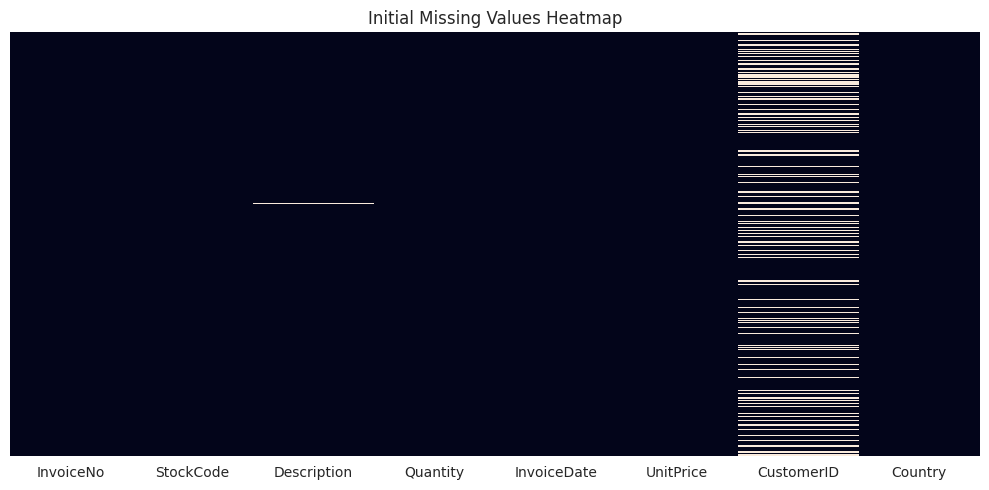

<Figure size 1000x500 with 0 Axes>

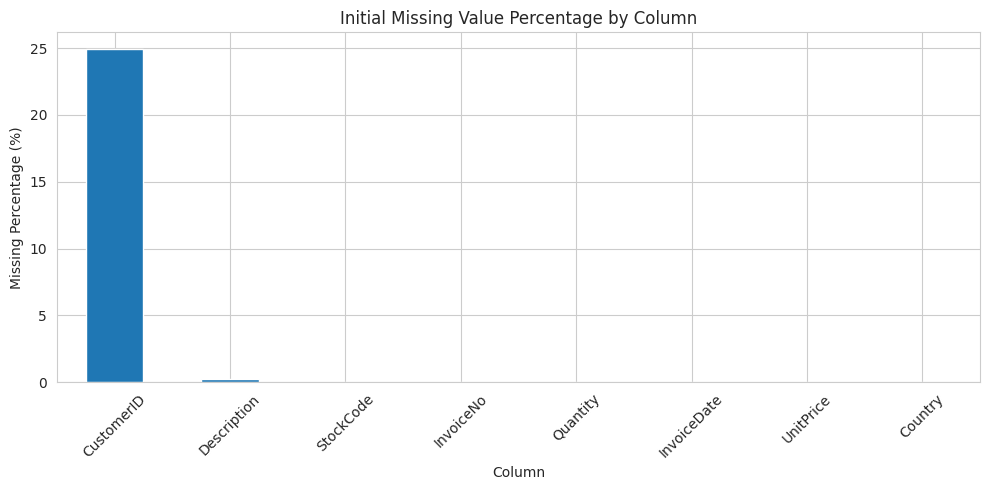

In [8]:
missing_report_initial = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isnull().sum().values,
    "Missing Percentage (%)": (df.isnull().mean() * 100).round(2).values,
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Data Type": df.dtypes.astype(str).values
})

display(missing_report_initial)

missing_report_initial.to_csv(
    os.path.join(tables_dir, "initial_missing_value_report.csv"),
    index=False
)
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Initial Missing Values Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "initial_missing_values_heatmap.png"), dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
missing_report_initial.sort_values("Missing Percentage (%)", ascending=False).plot(
    x="Column",
    y="Missing Percentage (%)",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)
plt.title("Initial Missing Value Percentage by Column")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "initial_missing_value_percentage.png"), dpi=300)
plt.show()


## 5. Create a cleaning log and remove exact duplicates

It records how many rows are removed at each cleaning step.


In [9]:
cleaning_log = []

def log_step(step, before_rows, after_rows):
    cleaning_log.append({
        "Cleaning Step": step,
        "Rows Before": before_rows,
        "Rows After": after_rows,
        "Rows Removed": before_rows - after_rows
    })

# Duplicate


duplicate_count = df.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated()].head())

before = len(df)
df = df.drop_duplicates()
after = len(df)

log_step("Duplicate records removed", before, after)


Duplicate rows found: 5268


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


## 6. Correction of the date field and handling missing customer identifiers


In [10]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

print("InvoiceDate converted to datetime")
print("Missing InvoiceDate values:", df["InvoiceDate"].isnull().sum())

# Missing Customer id
missing_customer = df["CustomerID"].isnull().sum()
print("Missing CustomerID records:", missing_customer)

if missing_customer > 0:
    display(df[df["CustomerID"].isnull()].head())
before = len(df)
df = df.dropna(subset=["CustomerID"])
after = len(df)
log_step("Missing CustomerID records removed", before, after)

missing_description = df["Description"].isnull().sum()

print("Missing Description records after CustomerID removal:", missing_description)

if missing_description > 0:
    missing_description_rows = df[df["Description"].isnull()]
    display(missing_description_rows.head())

    description_investigation = missing_description_rows[[
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]]

    display(description_investigation.head())

    description_investigation.to_csv(
        os.path.join(tables_dir, "missing_description_investigation.csv"),
        index=False
    )


InvoiceDate converted to datetime
Missing InvoiceDate values: 0
Missing CustomerID records: 135037


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


Missing Description records after CustomerID removal: 0


## 7. Investigate adjustment and cancelled invoices

Customer segmentation should be based on completed purchases. Invoice numbers beginning with `A` are checked as adjustment records, while numbers beginning with `C` represent cancellations or returns and the excluded records are inspected and saved as separate CSV files before being removed


In [11]:
adjustment_rows = df[df["InvoiceNo"].astype(str).str.startswith("A")]

print("Adjustment invoice records found:", len(adjustment_rows))

if len(adjustment_rows) > 0:
    display(adjustment_rows.head())

    adjustment_rows.to_csv(
        os.path.join(tables_dir, "adjustment_invoice_records.csv"),
        index=False
    )

before = len(df)
df = df[~df["InvoiceNo"].astype(str).str.startswith("A")]
after = len(df)

log_step("Adjustment invoice records removed", before, after)

# INVESTIGATE AND REMOVE CANCELLED INVOICES

cancelled_rows = df[df["InvoiceNo"].astype(str).str.startswith("C")]

print("Cancelled invoice records found:", len(cancelled_rows))

if len(cancelled_rows) > 0:
    display(cancelled_rows.head())

    cancelled_rows.to_csv(
        os.path.join(tables_dir, "cancelled_invoice_records.csv"),
        index=False
    )

before = len(df)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
after = len(df)

log_step("Cancelled invoice records removed", before, after)


Adjustment invoice records found: 0
Cancelled invoice records found: 8872


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


The current run contains no `A` adjustment invoices after the earlier filtering, but it contains 8,872 cancelled invoice rows. A sample of the cancelled records is displayed.


## 8. Remove non-positive quantity and price records

This block checks for quantities less than or equal to zero and prices less than or equal to zero. Any affected rows are saved for reference and then removed, with the row changes added to the cleaning log.


In [12]:
invalid_quantity_rows = df[df["Quantity"] <= 0]

print("Invalid quantity records found:", len(invalid_quantity_rows))

if len(invalid_quantity_rows) > 0:
    display(invalid_quantity_rows.head())

    invalid_quantity_rows.to_csv(
        os.path.join(tables_dir, "invalid_quantity_records.csv"),
        index=False
    )

before = len(df)
df = df[df["Quantity"] > 0]
after = len(df)

log_step("Invalid quantity records removed", before, after)

# REMOVE INVALID UNIT PRICE VALUES

invalid_price_rows = df[df["UnitPrice"] <= 0]

print("Invalid UnitPrice records found:", len(invalid_price_rows))

if len(invalid_price_rows) > 0:
    display(invalid_price_rows.head())

    invalid_price_rows.to_csv(
        os.path.join(tables_dir, "invalid_unitprice_records.csv"),
        index=False
    )

before = len(df)
df = df[df["UnitPrice"] > 0]
after = len(df)

log_step("Invalid UnitPrice records removed", before, after)


Invalid quantity records found: 0
Invalid UnitPrice records found: 40


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom


## 9. Standardise data types and calculate transaction value
Customer IDs are converted to integers, identifier fields are stored as strings, and `TotalAmount` is calculated as `Quantity × UnitPrice`.

The output lists the final data types and displays a few rows showing the quantity, unit price and calculated total amount.


In [13]:
df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)
df["Country"] = df["Country"].astype(str)

print("Final data types")
display(df.dtypes)

#  CREATE TOTAL AMOUNT

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

display(df[["Quantity", "UnitPrice", "TotalAmount"]].head())


Final data types


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,int64
Country,object


,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 10. Validate the cleaning rules and summarise removed records


In [14]:
validation_report = pd.DataFrame({
    "Validation Check": [
        "Missing CustomerID",
        "Missing InvoiceDate",
        "Duplicate Records",
        "Cancelled Invoices",
        "Adjustment Invoices",
        "Quantity <= 0",
        "UnitPrice <= 0",
        "TotalAmount <= 0"
    ],
    "Remaining Records": [
        df["CustomerID"].isnull().sum(),
        df["InvoiceDate"].isnull().sum(),
        df.duplicated().sum(),
        df["InvoiceNo"].astype(str).str.startswith("C").sum(),
        df["InvoiceNo"].astype(str).str.startswith("A").sum(),
        (df["Quantity"] <= 0).sum(),
        (df["UnitPrice"] <= 0).sum(),
        (df["TotalAmount"] <= 0).sum()
    ]
})

display(validation_report)

validation_report.to_csv(
    os.path.join(tables_dir, "final_validation_report.csv"),
    index=False
)

#  CLEANING SUMMARY TABLE

cleaning_summary = pd.DataFrame(cleaning_log)

display(cleaning_summary)

cleaning_summary.to_csv(
    os.path.join(tables_dir, "cleaning_summary_table.csv"),
    index=False
)

cleaning_summary["Percentage Removed"] = (
    cleaning_summary["Rows Removed"] /
    cleaning_summary["Rows Before"] * 100
).round(2)


,Validation Check,Remaining Records
0,Missing CustomerID,0
1,Missing InvoiceDate,0
2,Duplicate Records,0
3,Cancelled Invoices,0
4,Adjustment Invoices,0
5,Quantity <= 0,0
6,UnitPrice <= 0,0
7,TotalAmount <= 0,0


,Cleaning Step,Rows Before,Rows After,Rows Removed
0,Duplicate records removed,541909,536641,5268
1,Missing CustomerID records removed,536641,401604,135037
2,Adjustment invoice records removed,401604,401604,0
3,Cancelled invoice records removed,401604,392732,8872
4,Invalid quantity records removed,392732,392732,0
5,Invalid UnitPrice records removed,392732,392692,40


## 11. Describe the cleaned dataset
This gives a clear before-and-after summary and confirms the coverage of the final transaction data.


In [15]:
dataset_statistics = pd.DataFrame({
    "Metric": [
        "Original Records",
        "Final Records",
        "Records Removed",
        "Percentage Removed",
        "Final Columns",
        "Unique Customers",
        "Unique Products",
        "Unique Invoices",
        "Countries",
        "Start Date",
        "End Date",
        "Total Revenue",
        "Average Transaction Value",
        "Average Quantity",
        "Average Unit Price"
    ],
    "Value": [
        original_rows,
        len(df),
        original_rows - len(df),
        round(((original_rows - len(df)) / original_rows) * 100, 2),
        df.shape[1],
        df["CustomerID"].nunique(),
        df["StockCode"].nunique(),
        df["InvoiceNo"].nunique(),
        df["Country"].nunique(),
        df["InvoiceDate"].min(),
        df["InvoiceDate"].max(),
        round(df["TotalAmount"].sum(), 2),
        round(df["TotalAmount"].mean(), 2),
        round(df["Quantity"].mean(), 2),
        round(df["UnitPrice"].mean(), 2)
    ]
})

display(dataset_statistics)

dataset_statistics.to_csv(
    os.path.join(tables_dir, "cleaned_dataset_statistics.csv"),
    index=False
)


,Metric,Value
0,Original Records,541909
1,Final Records,392692
2,Records Removed,149217
3,Percentage Removed,27.54
4,Final Columns,9
5,Unique Customers,4338
6,Unique Products,3665
7,Unique Invoices,18532
8,Countries,37
9,Start Date,2010-12-01 08:26:00


In the current run, 392,692 transaction rows remain after cleaning. The table also reports 4,338 customers and the complete transaction date range used in the later RFM stage.


## 12. Examine skewness and potential outliers

 Skewness and kurtosis are calculated for `Quantity`, `UnitPrice` and `TotalAmount`. The IQR method is then used to count values outside the usual statistical bounds.


In [16]:
numeric_cols = ["Quantity", "UnitPrice", "TotalAmount"]

skew_kurtosis_report = pd.DataFrame({
    "Feature": numeric_cols,
    "Skewness": [df[col].skew() for col in numeric_cols],
    "Kurtosis": [df[col].kurtosis() for col in numeric_cols]
})

display(skew_kurtosis_report)

skew_kurtosis_report.to_csv(
    os.path.join(tables_dir, "skewness_kurtosis_report.csv"),
    index=False
)

#  OUTLIER SUMMARY USING IQR

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_percentage = round((outlier_count / len(df)) * 100, 2)

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": outlier_percentage
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

outlier_summary_df.to_csv(
    os.path.join(tables_dir, "outlier_summary_iqr.csv"),
    index=False
)


,Feature,Skewness,Kurtosis
0,Quantity,407.345663,175940.085113
1,UnitPrice,202.740861,57398.335042
2,TotalAmount,448.521779,229148.857198


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,Quantity,2.00,12.00,10.00,-13.000,27.000,25616,6.52
1,UnitPrice,1.25,3.75,2.50,-2.500,7.500,34112,8.69
2,TotalAmount,4.95,19.80,14.85,-17.325,42.075,31231,7.95


## 13. Create a transaction-level summary


In [17]:
transaction_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Total Revenue",
        "Average Transaction Value",
        "Median Transaction Value",
        "Minimum Transaction Value",
        "Maximum Transaction Value",
        "Average Quantity",
        "Median Quantity",
        "Average Unit Price",
        "Median Unit Price"
    ],
    "Value": [
        len(df),
        round(df["TotalAmount"].sum(), 2),
        round(df["TotalAmount"].mean(), 2),
        round(df["TotalAmount"].median(), 2),
        round(df["TotalAmount"].min(), 2),
        round(df["TotalAmount"].max(), 2),
        round(df["Quantity"].mean(), 2),
        round(df["Quantity"].median(), 2),
        round(df["UnitPrice"].mean(), 2),
        round(df["UnitPrice"].median(), 2)
    ]
})

display(transaction_summary)

transaction_summary.to_csv(
    os.path.join(tables_dir, "transaction_summary.csv"),
    index=False
)


,Metric,Value
0,Total Transactions,392692.00
1,Total Revenue,8887208.89
2,Average Transaction Value,22.63
3,Median Transaction Value,12.45
4,Minimum Transaction Value,0.00
5,Maximum Transaction Value,168469.60
6,Average Quantity,13.12
7,Median Quantity,6.00
8,Average Unit Price,3.13
9,Median Unit Price,1.95


## 14. Build country, customer, product and monthly summaries


In [18]:
country_summary = df.groupby("Country").agg(
    Transactions=("InvoiceNo", "count"),
    Revenue=("TotalAmount", "sum"),
    Customers=("CustomerID", "nunique")
).sort_values("Revenue", ascending=False)

country_summary["Revenue Percentage (%)"] = (
    country_summary["Revenue"] / country_summary["Revenue"].sum() * 100
).round(2)

display(country_summary.head(15))

country_summary.to_csv(
    os.path.join(tables_dir, "country_summary.csv")
)

#  TOP CUSTOMERS WITH EXTRA METRICS

top_customers = df.groupby("CustomerID").agg(
    Orders=("InvoiceNo", "nunique"),
    TotalSpent=("TotalAmount", "sum"),
    QuantityPurchased=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique")
).sort_values("TotalSpent", ascending=False)

top_customers["AverageOrderValue"] = (
    top_customers["TotalSpent"] / top_customers["Orders"]
).round(2)

display(top_customers.head(20))

top_customers.to_csv(
    os.path.join(tables_dir, "top_customers_summary.csv")
)

#TOP PRODUCTS SUMMARY

top_products = df.groupby(["StockCode", "Description"]).agg(
    QuantitySold=("Quantity", "sum"),
    Revenue=("TotalAmount", "sum"),
    Transactions=("InvoiceNo", "count")
).sort_values("Revenue", ascending=False)

display(top_products.head(20))

top_products.to_csv(
    os.path.join(tables_dir, "top_products_summary.csv")
)

# MONTHLY TRANSACTION SUMMARY

monthly_summary = df.set_index("InvoiceDate").resample("ME").agg(
    Transactions=("InvoiceNo", "count"),
    Revenue=("TotalAmount", "sum"),
    Customers=("CustomerID", "nunique")
)

display(monthly_summary)

monthly_summary.to_csv(
    os.path.join(tables_dir, "monthly_transaction_summary.csv")
)


,Transactions,Revenue,Customers,Revenue Percentage (%)
Country,,,,
United Kingdom,349203,7285024.644,3920,81.97
Netherlands,2359,285446.340,9,3.21
EIRE,7226,265262.460,3,2.98
Germany,9025,228678.400,94,2.57
France,8326,208934.310,87,2.35
Australia,1181,138453.810,9,1.56
Spain,2479,61558.560,30,0.69
Switzerland,1841,56443.950,21,0.64
Belgium,2031,41196.340,25,0.46


,Orders,TotalSpent,QuantityPurchased,UniqueProducts,AverageOrderValue
CustomerID,,,,,
14646,73,280206.02,196915,700,3838.44
18102,60,259657.30,64124,150,4327.62
17450,46,194390.79,69973,124,4225.89
16446,2,168472.50,80997,3,84236.25
14911,201,143711.17,80240,1787,714.98
12415,21,124914.53,77374,444,5948.31
14156,55,117210.08,57768,714,2131.09
17511,31,91062.38,64549,453,2937.50
16029,63,80850.84,40108,44,1283.35


,,QuantitySold,Revenue,Transactions
StockCode,Description,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
22423,REGENCY CAKESTAND 3 TIER,12374,142264.75,1713
85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10,2016
85099B,JUMBO BAG RED RETROSPOT,46078,85040.54,1615
23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,198
POST,POSTAGE,3120,77803.96,1099
47566,PARTY BUNTING,15279,68785.23,1389
84879,ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03,1395
M,Manual,6933,53419.93,279


,Transactions,Revenue,Customers
InvoiceDate,,,
2010-12-31,25670,570422.730,885
2011-01-31,20988,568101.310,741
2011-02-28,19706,446084.920,758
2011-03-31,26870,594081.760,974
2011-04-30,22433,468374.331,856
2011-05-31,28073,677355.150,1056
2011-06-30,26926,660046.050,991
2011-07-31,26580,598962.901,949
2011-08-31,26790,644051.040,935


## 15. Visualise how many rows each cleaning rule removed


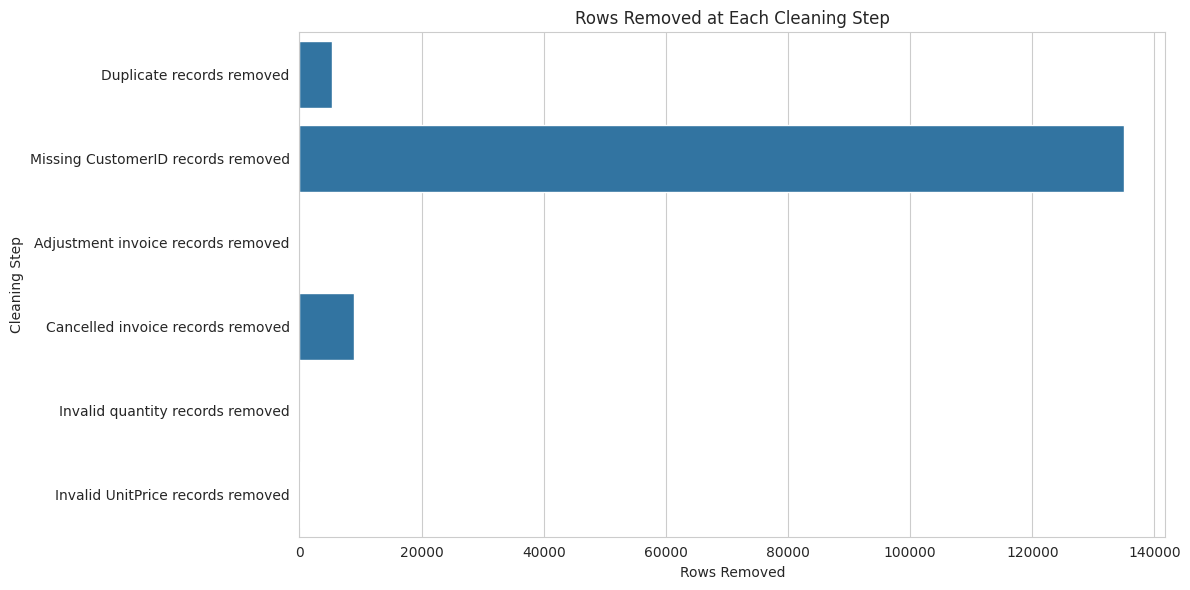

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=cleaning_summary,
    x="Rows Removed",
    y="Cleaning Step"
)
plt.title("Rows Removed at Each Cleaning Step")
plt.xlabel("Rows Removed")
plt.ylabel("Cleaning Step")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "cleaning_summary_rows_removed.png"), dpi=300)
plt.show()


## 16. Visualise numerical distributions and outliers


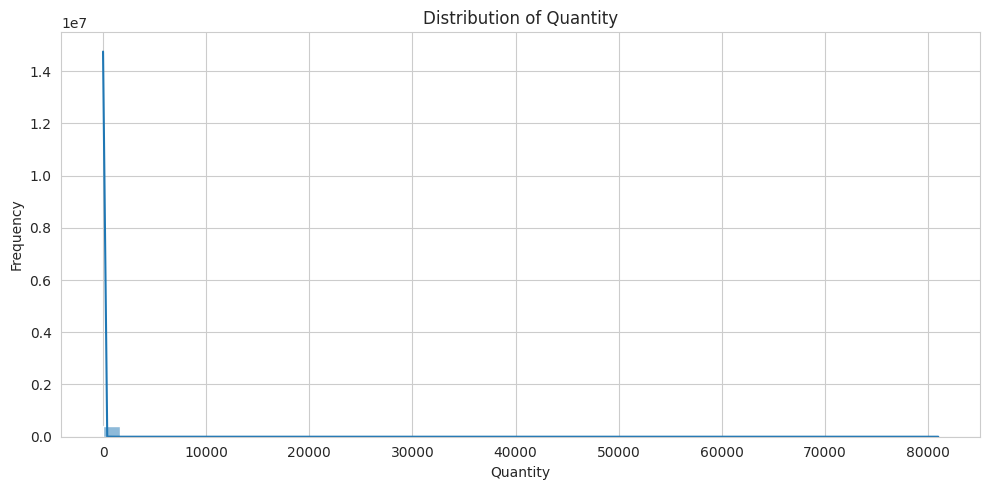

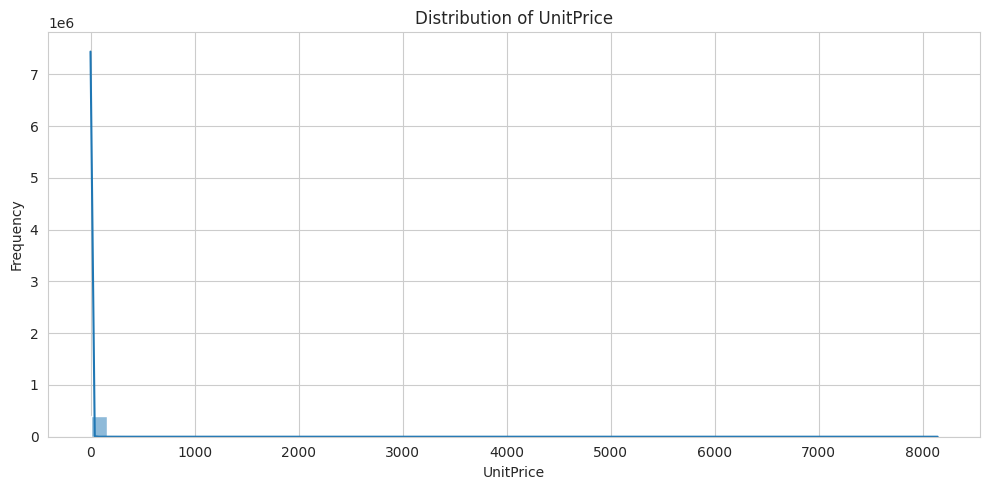

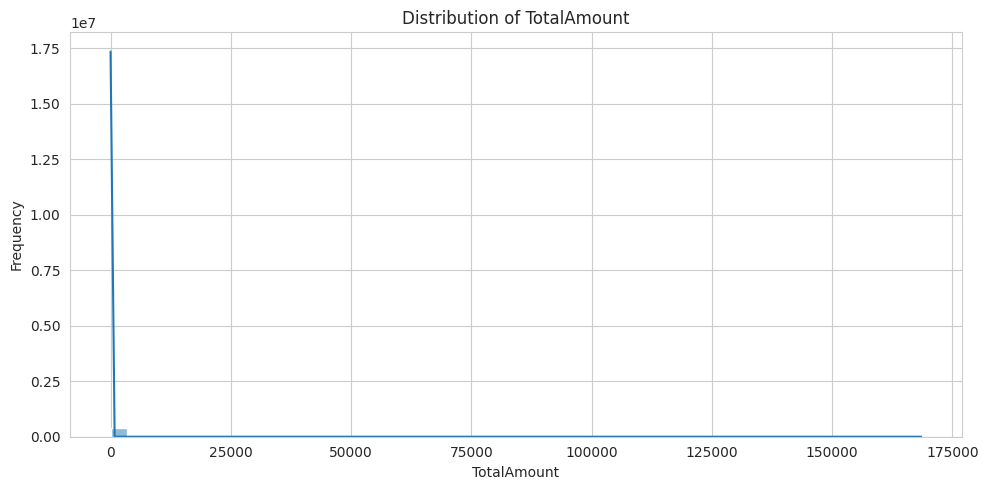

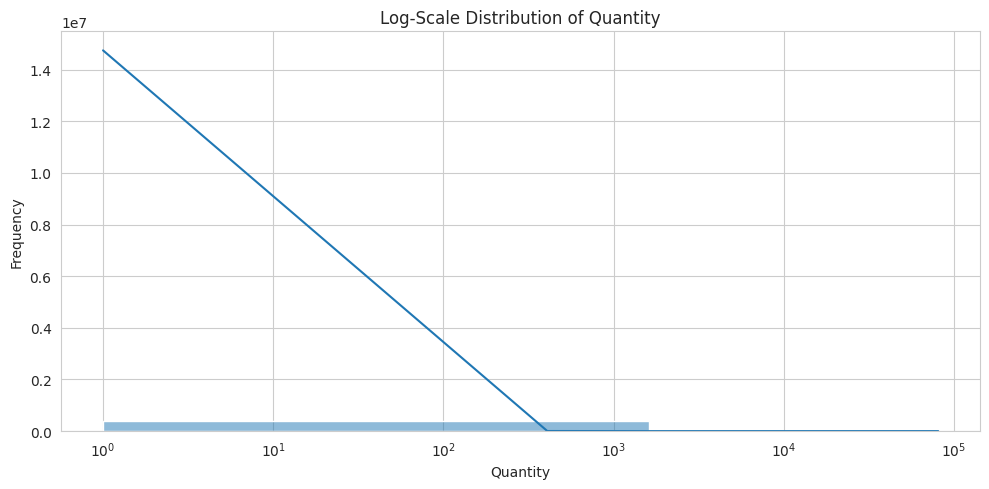

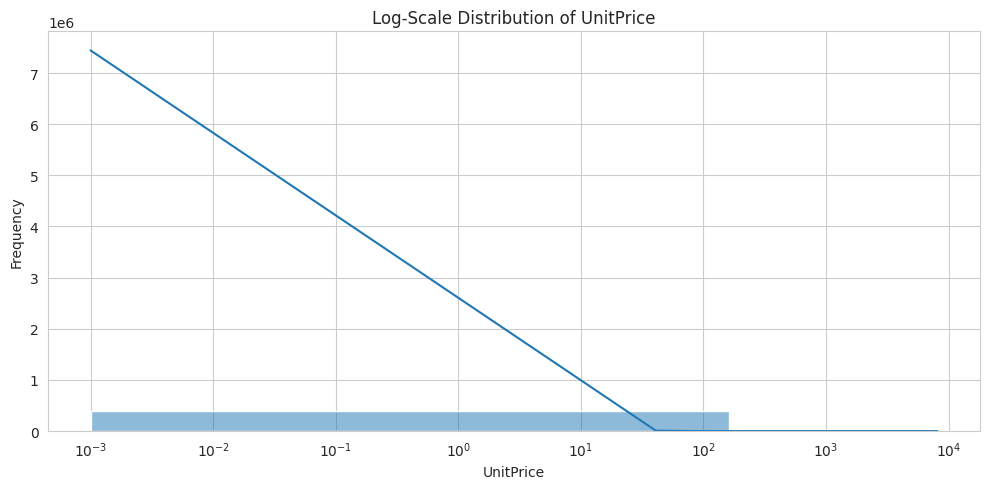

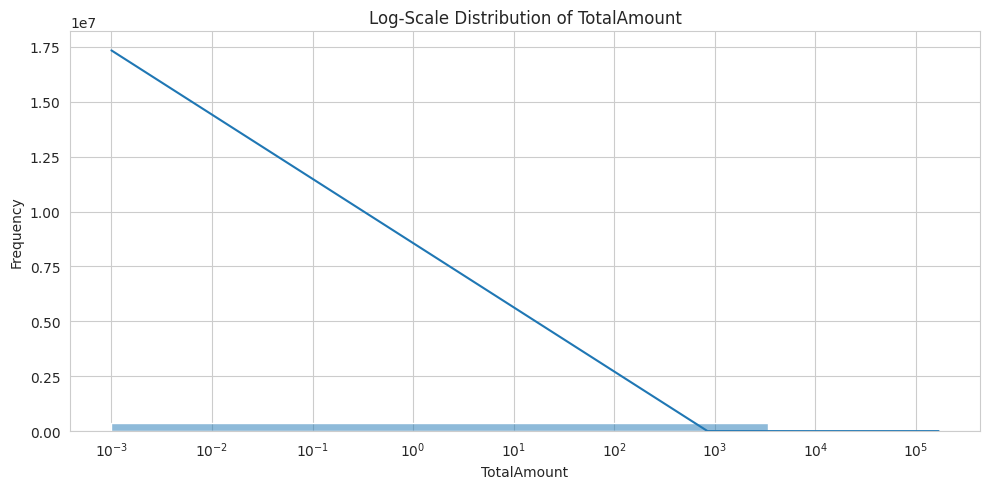

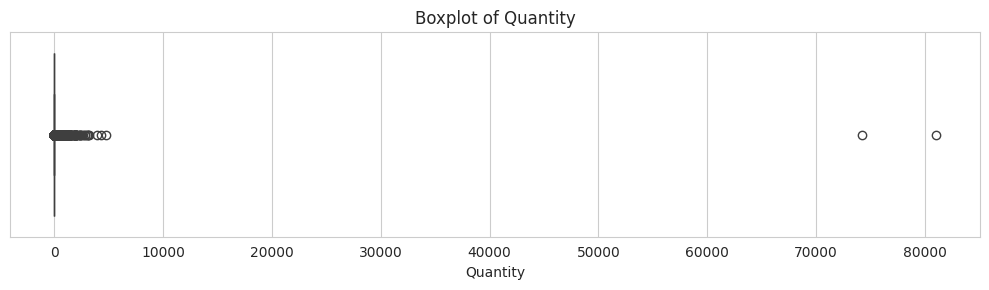

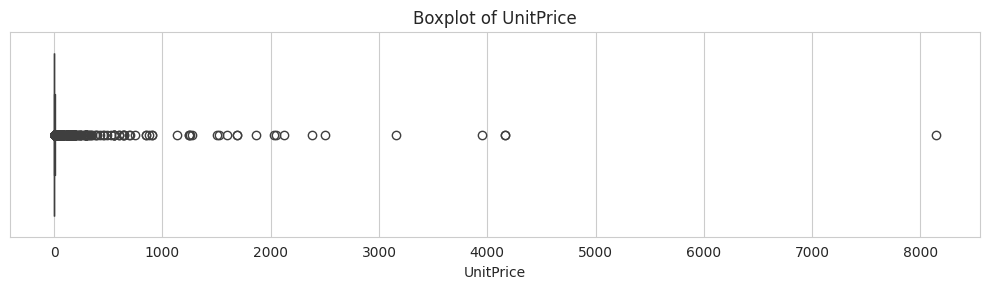

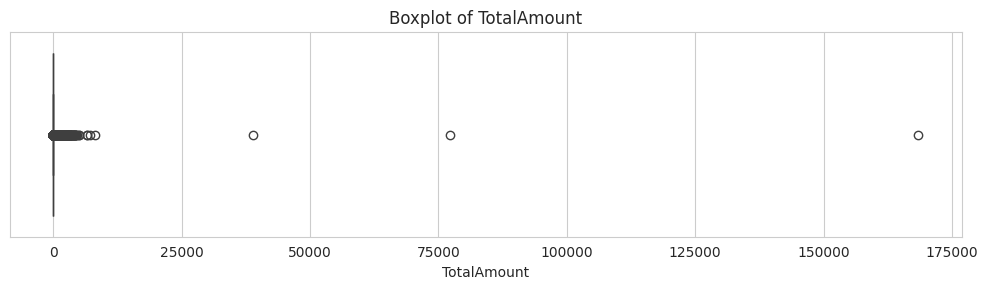

In [20]:
for col in numeric_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f"{col}_distribution.png"), dpi=300)
    plt.show()

# VISUALISATIONS: LOG-SCALE DISTRIBUTIONS

for col in numeric_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=50, kde=True)
    plt.xscale("log")
    plt.title(f"Log-Scale Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f"{col}_log_scale_distribution.png"), dpi=300)
    plt.show()

#VISUALISATIONS: BOXPLOTS

for col in numeric_cols:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f"{col}_boxplot.png"), dpi=300)
    plt.show()


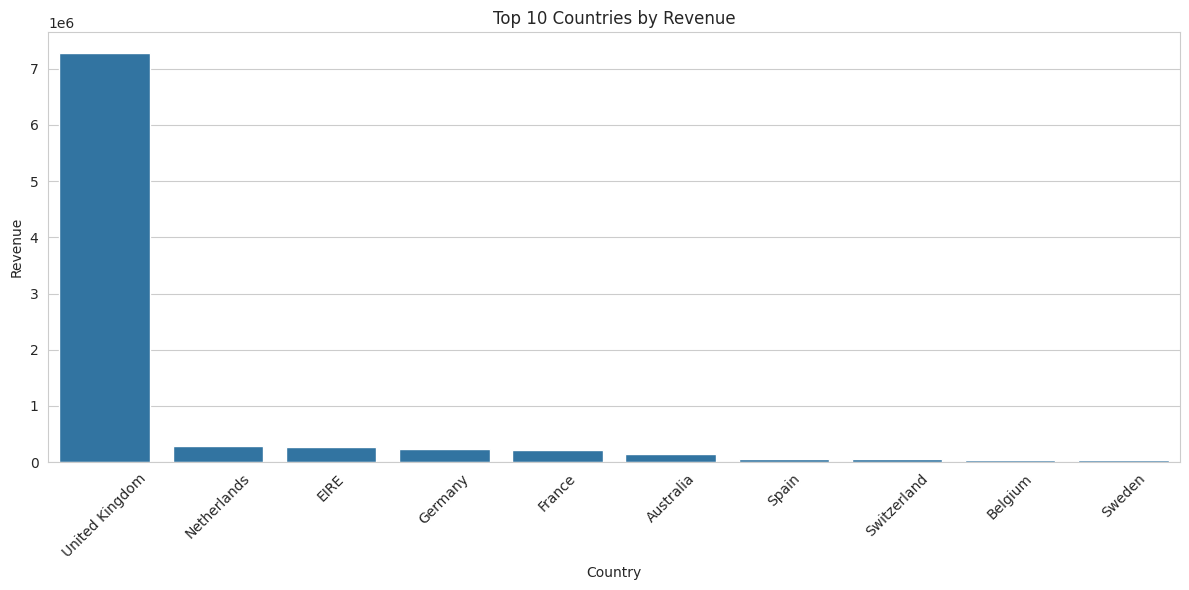

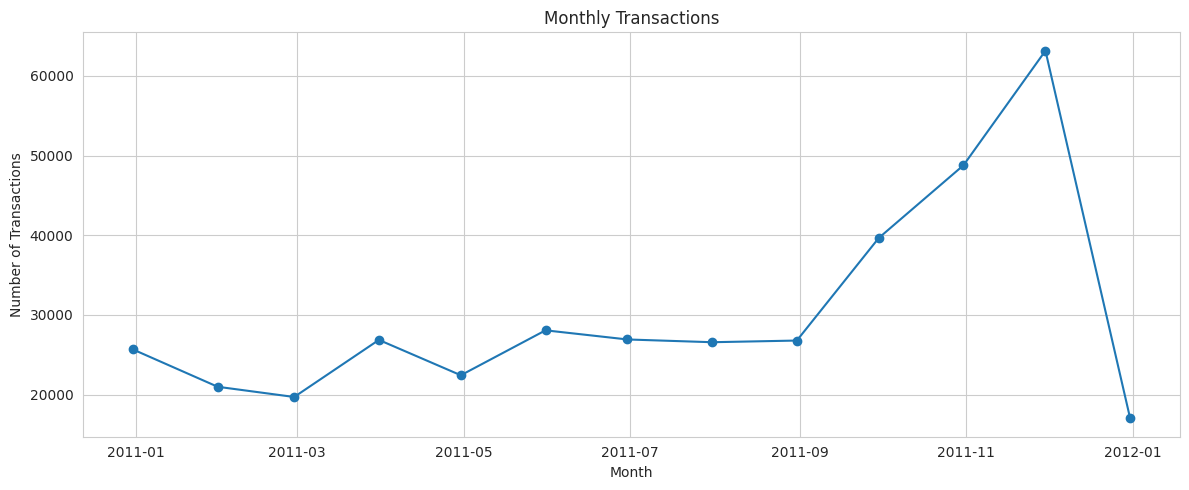

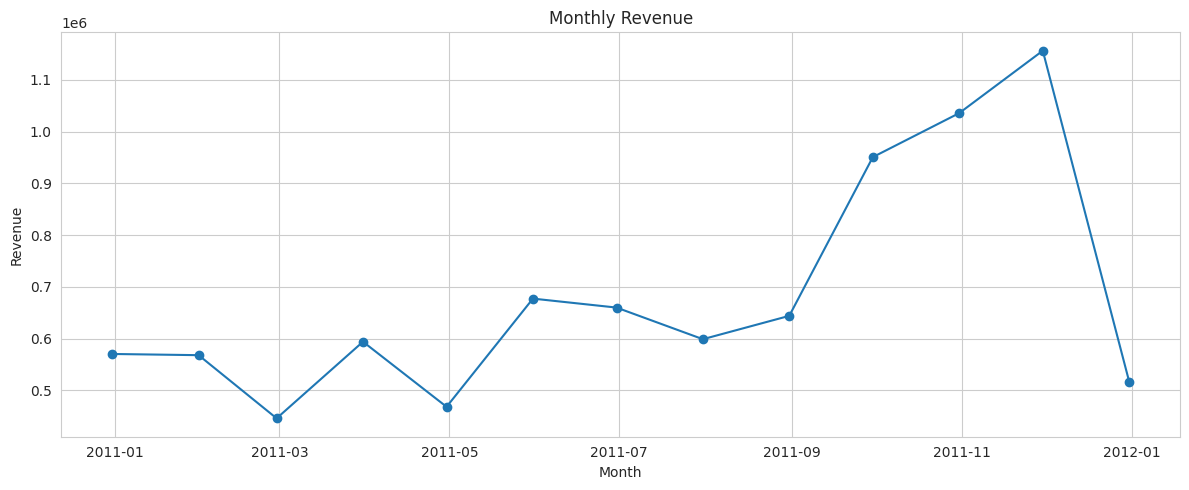

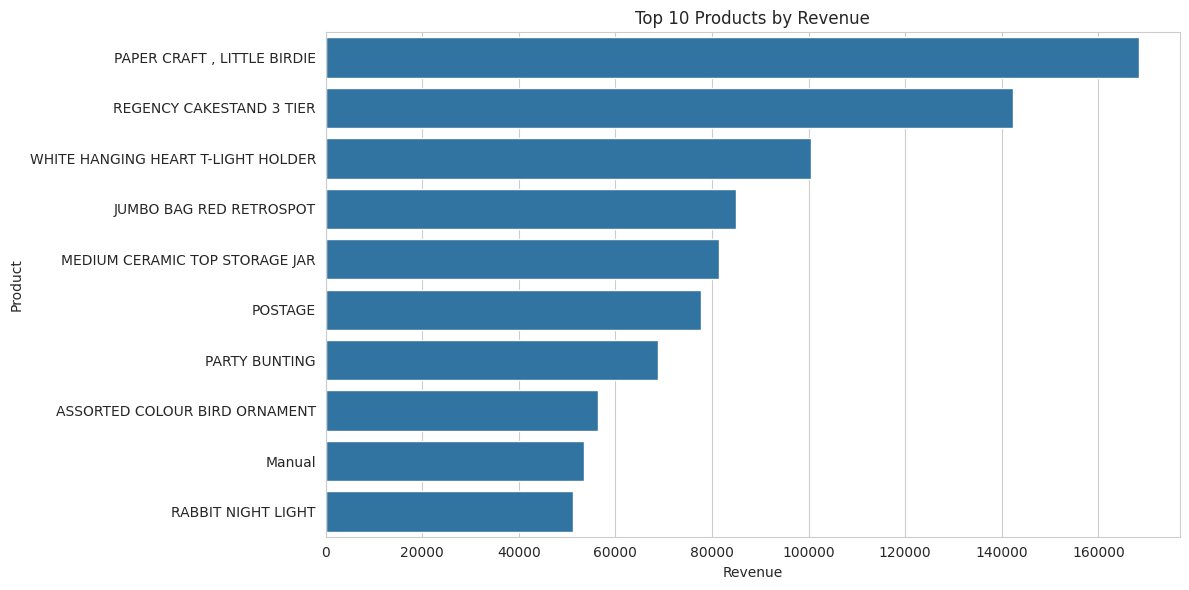

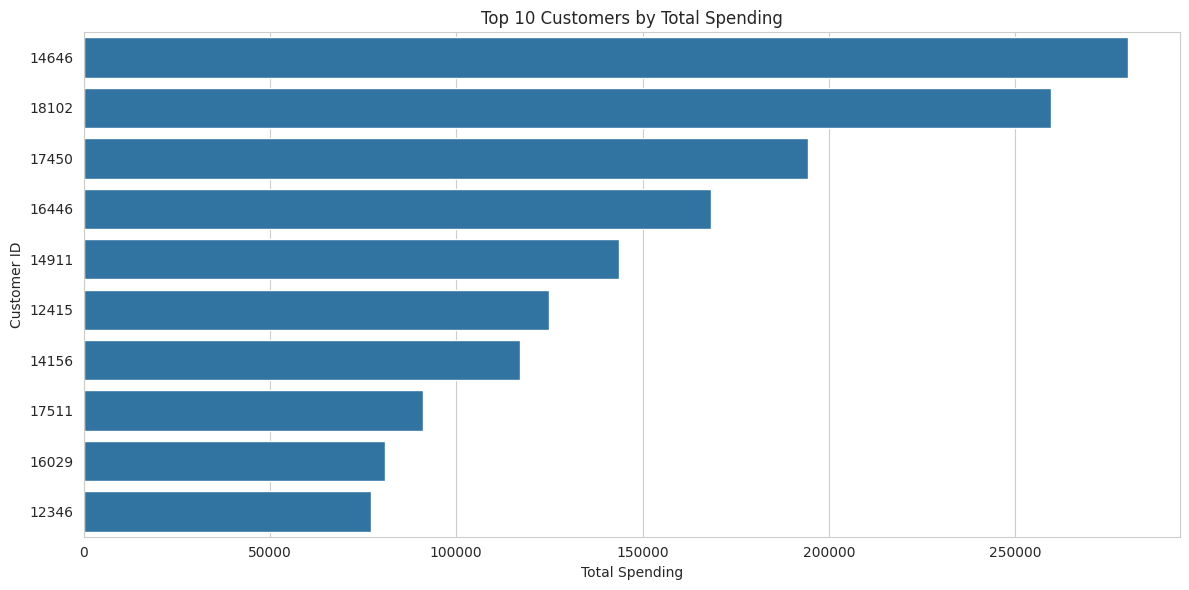

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=country_summary.head(10).index,
    y=country_summary.head(10)["Revenue"]
)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "top_10_countries_by_revenue.png"), dpi=300)
plt.show()

#VISUALISATIONS: MONTHLY TRANSACTIONS

plt.figure(figsize=(12, 5))
plt.plot(monthly_summary.index, monthly_summary["Transactions"], marker="o")
plt.title("Monthly Transactions")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "monthly_transactions.png"), dpi=300)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_summary.index, monthly_summary["Revenue"], marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "monthly_revenue.png"), dpi=300)
plt.show()

#TOP PRODUCTS

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_products.head(10)["Revenue"],
    y=[str(idx[1]) for idx in top_products.head(10).index]
)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "top_10_products_by_revenue.png"), dpi=300)
plt.show()

# TOP CUSTOMERS

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_customers.head(10)["TotalSpent"],
    y=top_customers.head(10).index.astype(str)
)
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "top_10_customers_by_spending.png"), dpi=300)
plt.show()


## 17. Run the final quality report and export the cleaned data

This is the final checkpoint before moving to customer-level feature engineering(**RFM**)


In [22]:
final_quality_report = pd.DataFrame({
    "Metric": [
        "Ready for RFM Feature Engineering",
        "Missing Values Remaining",
        "Duplicate Records Remaining",
        "Invalid Quantity Remaining",
        "Invalid UnitPrice Remaining",
        "Invalid TotalAmount Remaining",
        "Cancelled Invoices Remaining",
        "Adjustment Invoices Remaining",
        "Final Dataset Shape"
    ],
    "Result": [
        "YES",
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df["Quantity"] <= 0).sum(),
        (df["UnitPrice"] <= 0).sum(),
        (df["TotalAmount"] <= 0).sum(),
        df["InvoiceNo"].astype(str).str.startswith("C").sum(),
        df["InvoiceNo"].astype(str).str.startswith("A").sum(),
        str(df.shape)
    ]
})

display(final_quality_report)

final_quality_report.to_csv(
    os.path.join(tables_dir, "final_quality_report.csv"),
    index=False
)

# EXPORTING CLEANED DATASET READY FOR RFM

cleaned_data_path = os.path.join(data_dir, "cleaned_online_retail_ready_for_rfm.csv")

df.to_csv(cleaned_data_path, index=False)

print("=" * 80)
print("DATA CLEANING COMPLETED SUCCESSFULLY")
print("Cleaned dataset saved at:", cleaned_data_path)
print("Dataset is ready for RFM Feature Engineering")
print("=" * 80)


,Metric,Result
0,Ready for RFM Feature Engineering,YES
1,Missing Values Remaining,0
2,Duplicate Records Remaining,0
3,Invalid Quantity Remaining,0
4,Invalid UnitPrice Remaining,0
5,Invalid TotalAmount Remaining,0
6,Cancelled Invoices Remaining,0
7,Adjustment Invoices Remaining,0
8,Final Dataset Shape,"(392692, 9)"


DATA CLEANING COMPLETED SUCCESSFULLY
Cleaned dataset saved at: Results/Data/cleaned_online_retail_ready_for_rfm.csv
Dataset is ready for RFM Feature Engineering


## 18. Independent final dataset check


In [23]:
print("="*60)
print("FINAL DATASET CHECK")
print("="*60)

df.info()

print("\nDataset Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

print("\nUnique Customers")
print(df["CustomerID"].nunique())

print("\nUnique Invoices")
print(df["InvoiceNo"].nunique())

print("\nDate Range")
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())


FINAL DATASET CHECK
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.0+ MB

Dataset Shape
(392692, 9)

Missing Values
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Duplicate Records
0

Unique Custo

## Part I checkpoint

At this point the cleaned transaction data has been validated and exported as `Results/Data/cleaned_online_retail_ready_for_rfm.csv`. The next section uses this file directly, so no intermediate re-upload is required when the notebook is run from top to bottom.


# Part II — RFM and Extended Customer Feature Engineering

This section converts the cleaned transaction table into one row per customer. It creates the core RFM variables and four extended behavioural variables used later in clustering.


## 20. Load the cleaned transaction dataset produced in Part I

The cleaned CSV generated above is loaded directly from the shared `Results/Data` folder. `InvoiceDate` is converted back to datetime because CSV files do not preserve datetime types.


In [24]:
# Location of the cleaned transaction dataset in Google Colab
input_file = os.path.join(data_dir, "cleaned_online_retail_ready_for_rfm.csv")

# Load the cleaned data
df = pd.read_csv(input_file)

# CSV files do not keep the datetime data type, so converting it again
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("=" * 70)
print("CUSTOMER FEATURE ENGINEERING")
print("=" * 70)

print("\nDataset Shape")
print(df.shape)

print("\nFirst Five Records")
display(df.head())

print("\nDataset Information")
df.info()

print("\nMissing Values")
display(df.isnull().sum())


CUSTOMER FEATURE ENGINEERING

Dataset Shape
(392692, 9)

First Five Records


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 27.0+ MB

Missing Values


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalAmount,0


## 21. Select the reference date
Recency needs a fixed date from which the last purchase of every customer is measured. The minimum and maximum transaction dates are checked. One day is added to the latest transaction date and this becomes the reference date.


In [25]:
# SELECT REFERENCE DATE

print("="*70)
print("REFERENCE DATE")
print("="*70)

print("Minimum Transaction Date :",
      df["InvoiceDate"].min())

print("Maximum Transaction Date :",
      df["InvoiceDate"].max())

# One day after the latest transaction

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("\nReference Date Used For Recency Calculation")

print(reference_date)


REFERENCE DATE
Minimum Transaction Date : 2010-12-01 08:26:00
Maximum Transaction Date : 2011-12-09 12:50:00

Reference Date Used For Recency Calculation
2011-12-10 12:50:00


## 22. Create the core RFM features
This block creates the three main variables used in RFM customer segmentation.The transactions are grouped by `CustomerID`. Recency is the number of days since the customer's latest purchase, Frequency is the number of unique invoices, and Monetary is the total amount spent.


In [26]:
# CREATE CORE RFM FEATURES

print("="*70)
print("CREATING CORE RFM FEATURES")
print("="*70)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

print("\nRFM Features Created")
display(rfm.head())

print("\nRFM Shape")
print(rfm.shape)


CREATING CORE RFM FEATURES

RFM Features Created


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40



RFM Shape
(4338, 4)


A customer-level RFM table with 4,338 customers and the columns `CustomerID`, `Recency`, `Frequency` and `Monetary`.


## 23. Create additional behavioural features
RFM gives the main customer measures, but extra variables can provide more information about buying behaviour.

**Extending Features** :Total quantity, number of different products and number of transaction lines are calculated for each customer. Average order value and average basket size are created.


In [27]:
# CREATE EXTENDED BEHAVIOURAL FEATURES

extended_features = df.groupby("CustomerID").agg(
    TotalQuantity=("Quantity", "sum"),
    ProductDiversity=("StockCode", "nunique"),
    TransactionCount=("InvoiceNo", "count")
).reset_index()

extended_features["AverageOrderValue"] = (
    rfm["Monetary"] / rfm["Frequency"]
).round(2)

extended_features["BasketSize"] = (
    extended_features["TotalQuantity"] / rfm["Frequency"]
).round(2)

print("\nExtended Behavioural Features Created")
display(extended_features.head())

print("\nExtended Features Shape")
print(extended_features.shape)



Extended Behavioural Features Created


,CustomerID,TotalQuantity,ProductDiversity,TransactionCount,AverageOrderValue,BasketSize
0,12346,74215,1,1,77183.60,74215.00
1,12347,2458,103,182,615.71,351.14
2,12348,2341,22,31,449.31,585.25
3,12349,631,73,73,1757.55,631.00
4,12350,197,17,17,334.40,197.00



Extended Features Shape
(4338, 6)


## 24. Merge all customer features


In [28]:
# MERGE RFM AND EXTENDED FEATURES

customer_features = rfm.merge(
    extended_features,
    on="CustomerID",
    how="left"
)

print("\nCustomer Feature Dataset Created")
display(customer_features.head())

print("\nCustomer Feature Dataset Shape")
print(customer_features.shape)



Customer Feature Dataset Created


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,ProductDiversity,TransactionCount,AverageOrderValue,BasketSize
0,12346,326,1,77183.60,74215,1,1,77183.60,74215.00
1,12347,2,7,4310.00,2458,103,182,615.71,351.14
2,12348,75,4,1797.24,2341,22,31,449.31,585.25
3,12349,19,1,1757.55,631,73,73,1757.55,631.00
4,12350,310,1,334.40,197,17,17,334.40,197.00



Customer Feature Dataset Shape
(4338, 9)


## 25. Validate the customer features

This block checks whether any invalid values were introduced during aggregation and merging and also all the Missing values, duplicate customer IDs and non-positive feature values are counted. The validation report is also saved as a CSV file.


In [29]:
# FEATURE VALIDATION

print("="*70)
print("FEATURE VALIDATION")
print("="*70)

validation_report = pd.DataFrame({
    "Validation Check": [
        "Missing Values",
        "Duplicate Customer IDs",
        "Recency <= 0",
        "Frequency <= 0",
        "Monetary <= 0",
        "AverageOrderValue <= 0",
        "BasketSize <= 0",
        "ProductDiversity <= 0"
    ],
    "Result": [
        customer_features.isnull().sum().sum(),
        customer_features["CustomerID"].duplicated().sum(),
        (customer_features["Recency"] <= 0).sum(),
        (customer_features["Frequency"] <= 0).sum(),
        (customer_features["Monetary"] <= 0).sum(),
        (customer_features["AverageOrderValue"] <= 0).sum(),
        (customer_features["BasketSize"] <= 0).sum(),
        (customer_features["ProductDiversity"] <= 0).sum()
    ]
})

display(validation_report)

validation_report.to_csv(
    os.path.join(tables_dir, "customer_feature_validation_report.csv"),
    index=False
)


FEATURE VALIDATION


,Validation Check,Result
0,Missing Values,0
1,Duplicate Customer IDs,0
2,Recency <= 0,0
3,Frequency <= 0,0
4,Monetary <= 0,0
5,AverageOrderValue <= 0,0
6,BasketSize <= 0,0
7,ProductDiversity <= 0,0


## 26. Review descriptive statistics

 Count, mean, standard deviation, minimum, quartiles and maximum are calculated for each numerical column.


In [30]:
# FEATURE STATISTICS

feature_statistics = customer_features.describe().T

display(feature_statistics)

feature_statistics.to_csv(
    os.path.join(tables_dir, "customer_feature_statistics.csv")
)


,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00,13813.2500,15299.50,16778.7500,18287.00
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02
TotalQuantity,4338.0,1187.644537,5043.619654,1.00,159.0000,378.00,989.7500,196915.00
ProductDiversity,4338.0,61.501153,85.366768,1.00,16.0000,35.00,77.0000,1787.00
TransactionCount,4338.0,90.523744,225.506968,1.00,17.0000,41.00,98.0000,7676.00
AverageOrderValue,4338.0,417.645724,1796.511343,3.45,177.8625,291.94,428.2800,84236.25
BasketSize,4338.0,252.462852,1312.769332,1.00,92.0000,161.00,270.0000,74215.00


## 27. Plot the feature distributions


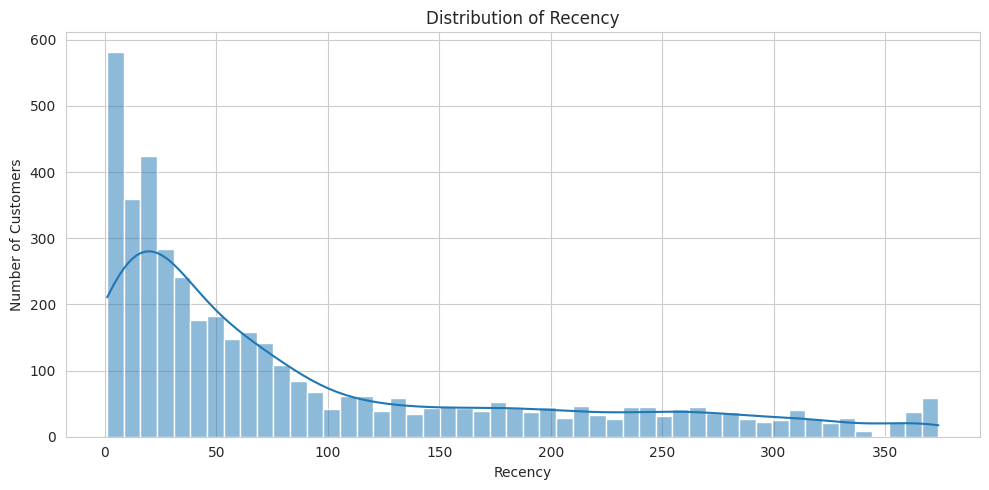

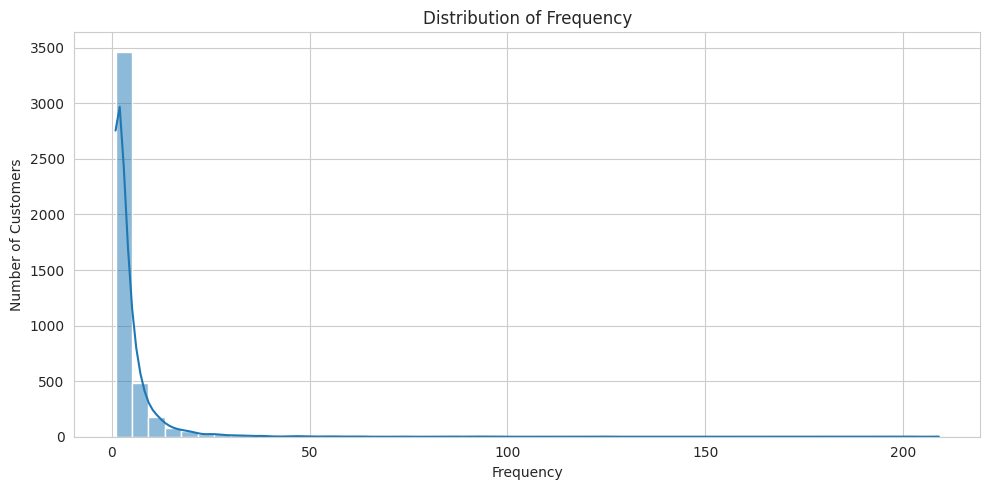

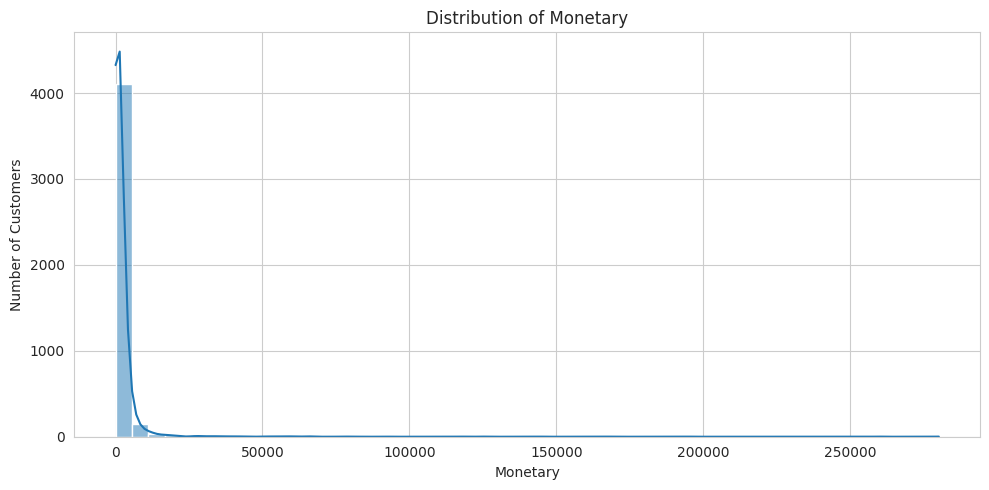

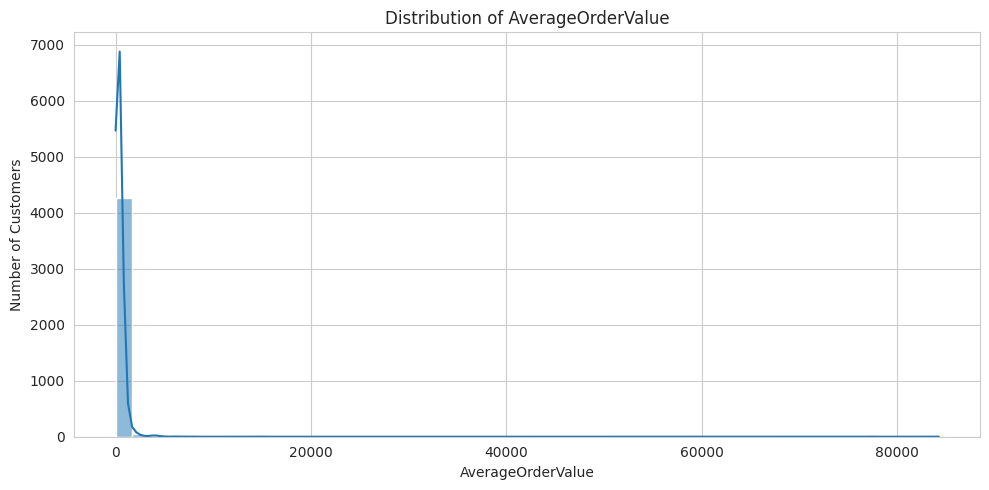

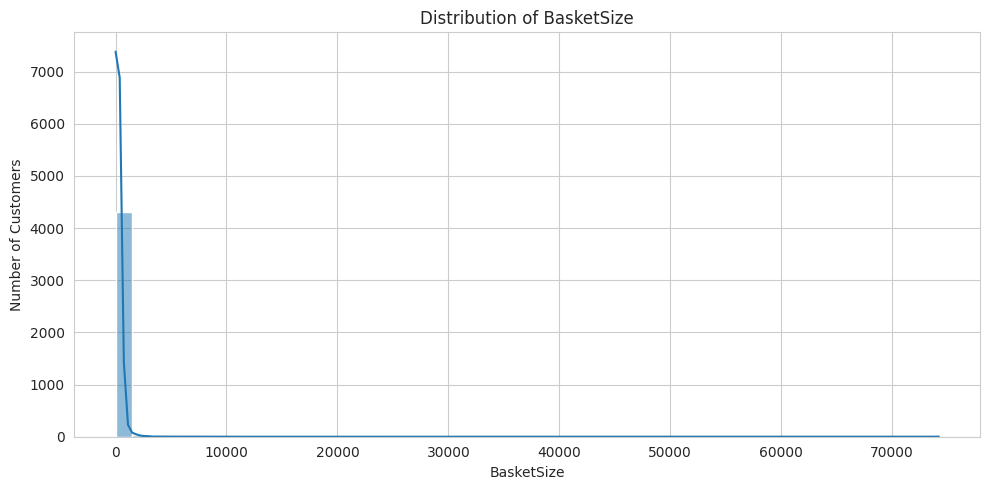

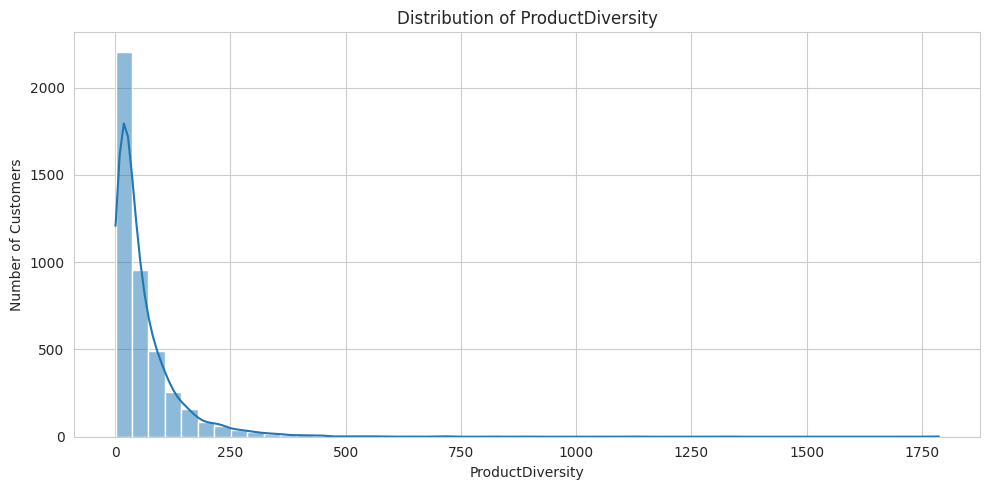

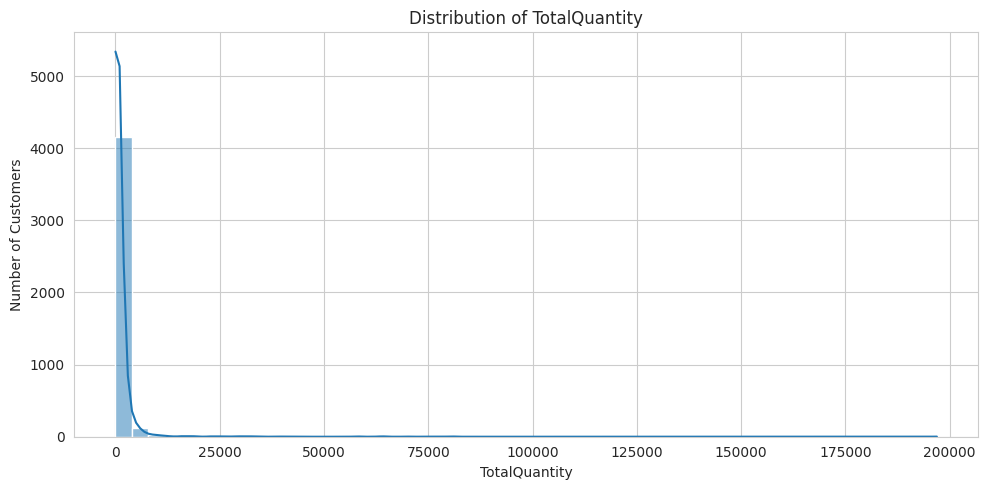

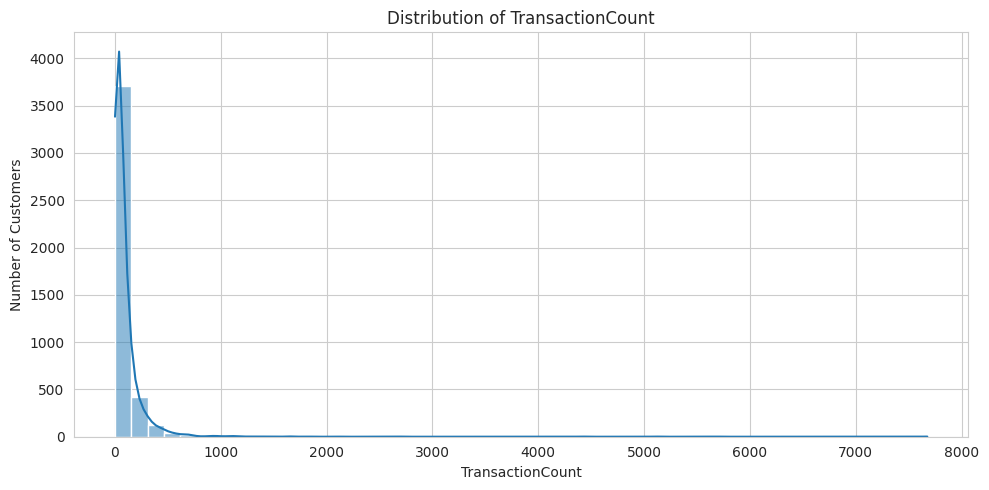

In [31]:
# FEATURE DISTRIBUTIONS

feature_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity",
    "TransactionCount"
]

for col in feature_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(customer_features[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.savefig(
        os.path.join(figures_dir, f"{col}_distribution.png"),
        dpi=300
    )
    plt.show()


## 28. Examine possible outliers using boxplots


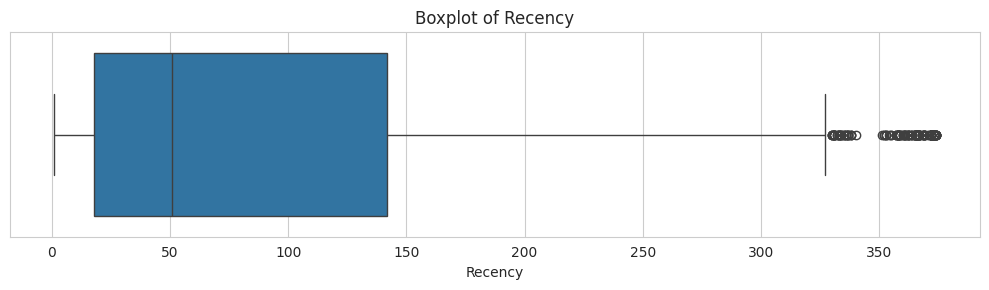

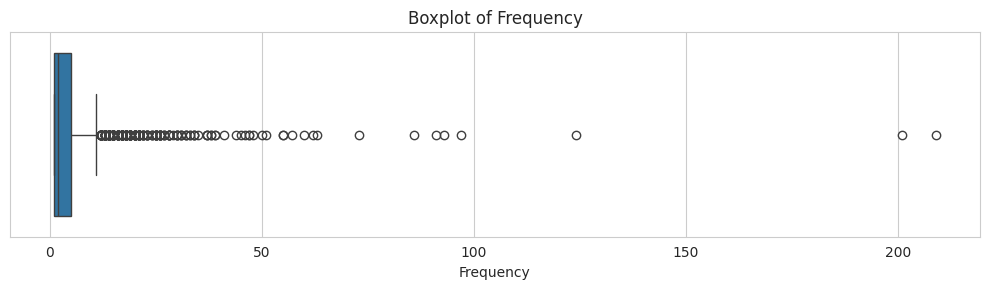

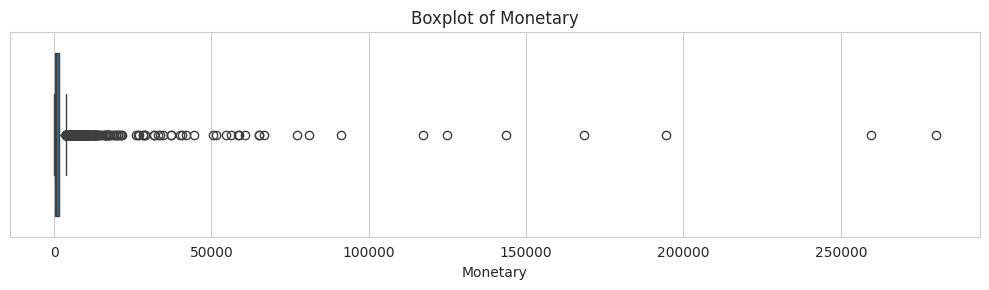

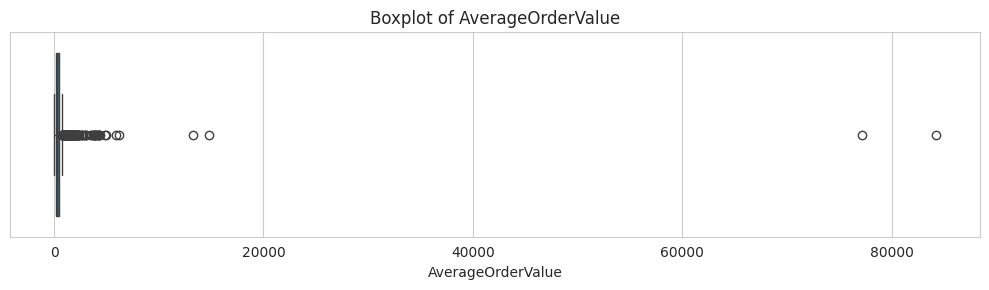

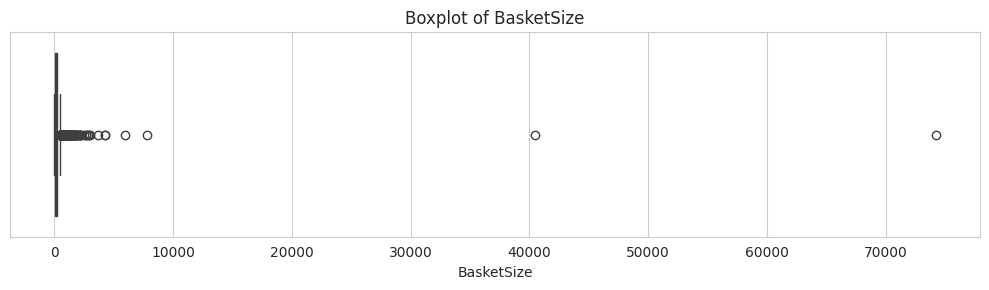

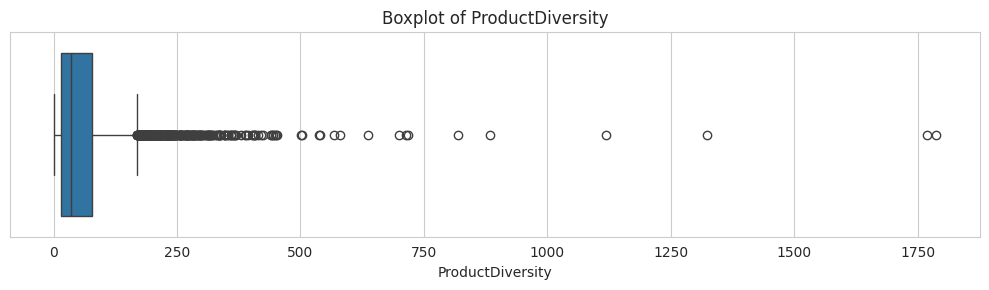

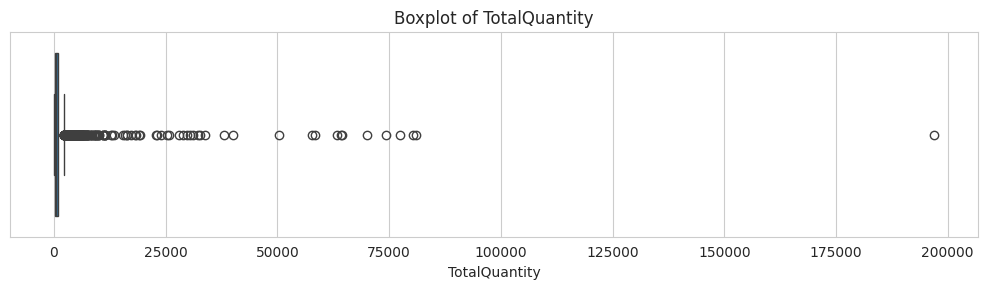

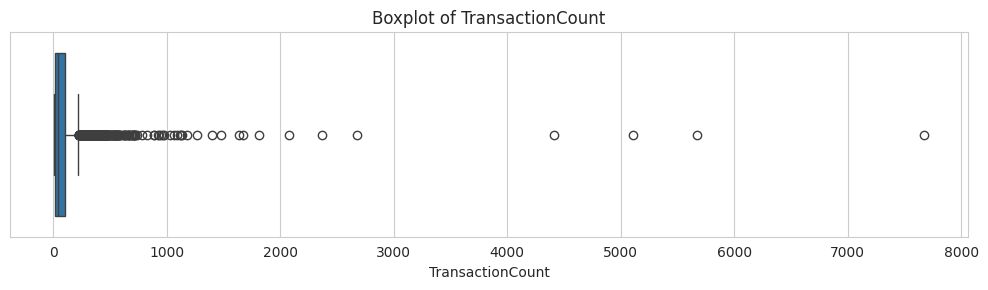

In [32]:
# BOXPLOTS FOR FEATURE OUTLIERS

for col in feature_cols:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=customer_features[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(figures_dir, f"{col}_boxplot.png"),
        dpi=300
    )
    plt.show()


## 29. Check correlation between features


,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity,TransactionCount
Recency,1.000000,-0.260578,-0.121831,-0.000116,0.007424,-0.300728,-0.123449,-0.206444
Frequency,-0.260578,1.000000,0.552780,0.019130,0.010800,0.692223,0.557216,0.757042
Monetary,-0.121831,0.552780,1.000000,0.393667,0.310523,0.385826,0.922942,0.425282
AverageOrderValue,-0.000116,0.019130,0.393667,1.000000,0.930907,0.035964,0.406581,0.030531
BasketSize,0.007424,0.010800,0.310523,0.930907,1.000000,0.024758,0.384052,0.018653
ProductDiversity,-0.300728,0.692223,0.385826,0.035964,0.024758,1.000000,0.408819,0.876773
TotalQuantity,-0.123449,0.557216,0.922942,0.406581,0.384052,0.408819,1.000000,0.433156
TransactionCount,-0.206444,0.757042,0.425282,0.030531,0.018653,0.876773,0.433156,1.000000


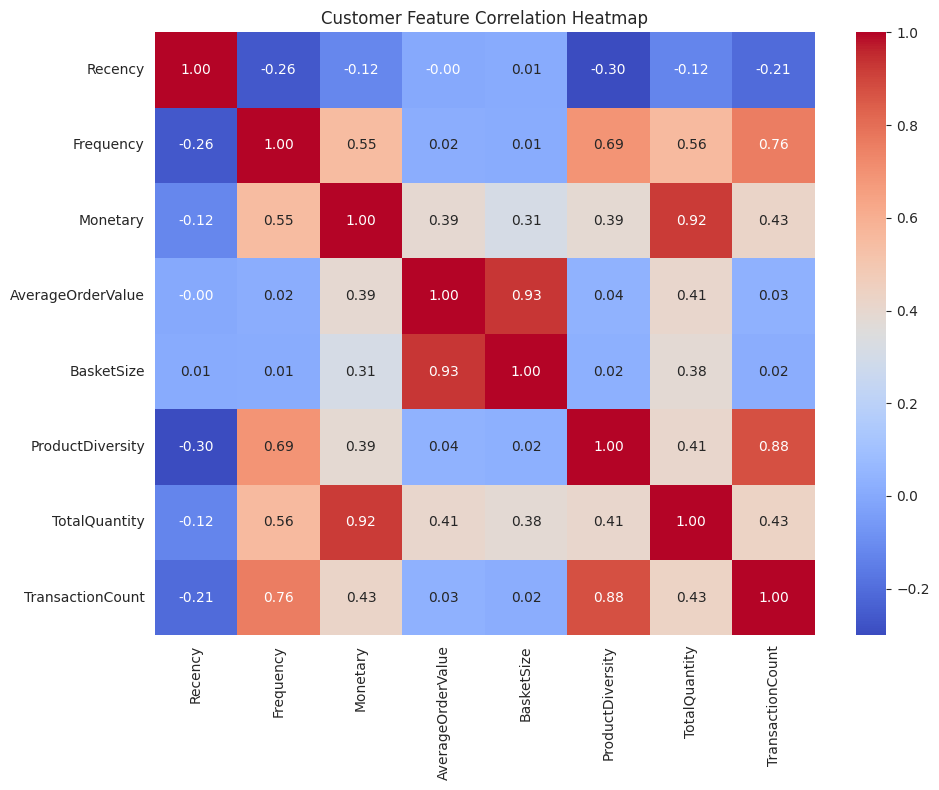

In [33]:
# CORRELATION CHECK

correlation_matrix = customer_features[feature_cols].corr()

display(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Customer Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, "customer_feature_correlation_heatmap.png"),
    dpi=300
)
plt.show()


## 30. Final customer-feature quality report


In [34]:
# FINAL CUSTOMER FEATURE QUALITY REPORT

customer_feature_report = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Features",
        "Missing Values",
        "Duplicate Customer IDs",
        "Average Recency",
        "Average Frequency",
        "Average Monetary",
        "Average Order Value",
        "Average Basket Size",
        "Average Product Diversity"
    ],
    "Value": [
        customer_features["CustomerID"].nunique(),
        customer_features.shape[1],
        customer_features.isnull().sum().sum(),
        customer_features["CustomerID"].duplicated().sum(),
        round(customer_features["Recency"].mean(), 2),
        round(customer_features["Frequency"].mean(), 2),
        round(customer_features["Monetary"].mean(), 2),
        round(customer_features["AverageOrderValue"].mean(), 2),
        round(customer_features["BasketSize"].mean(), 2),
        round(customer_features["ProductDiversity"].mean(), 2)
    ]
})

display(customer_feature_report)

customer_feature_report.to_csv(
    os.path.join(tables_dir, "customer_feature_report.csv"),
    index=False
)


,Metric,Value
0,Total Customers,4338.00
1,Total Features,9.00
2,Missing Values,0.00
3,Duplicate Customer IDs,0.00
4,Average Recency,92.54
5,Average Frequency,4.27
6,Average Monetary,2048.69
7,Average Order Value,417.65
8,Average Basket Size,252.46
9,Average Product Diversity,61.50


## 31. Export the customer feature dataset

The final customer-level data will be saved for the preprocessing and K-Means stages.


In [35]:
# EXPORT CUSTOMER FEATURE DATASET

customer_features.to_csv(
    os.path.join(data_dir, "customer_features_ready_for_preprocessing.csv"),
    index=False
)

print("="*70)
print("CUSTOMER FEATURE ENGINEERING COMPLETED SUCCESSFULLY")
print("="*70)

print("\nCustomer-level feature dataset saved as:")
print(os.path.join(data_dir, "customer_features_ready_for_preprocessing.csv"))

print("\nFinal Customer Feature Shape:")
print(customer_features.shape)

display(customer_features.head())


CUSTOMER FEATURE ENGINEERING COMPLETED SUCCESSFULLY

Customer-level feature dataset saved as:
Results/Data/customer_features_ready_for_preprocessing.csv

Final Customer Feature Shape:
(4338, 9)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,ProductDiversity,TransactionCount,AverageOrderValue,BasketSize
0,12346,326,1,77183.60,74215,1,1,77183.60,74215.00
1,12347,2,7,4310.00,2458,103,182,615.71,351.14
2,12348,75,4,1797.24,2341,22,31,449.31,585.25
3,12349,19,1,1757.55,631,73,73,1757.55,631.00
4,12350,310,1,334.40,197,17,17,334.40,197.00


## Part II checkpoint

The customer-level dataset has now been exported as `Results/Data/customer_features_ready_for_preprocessing.csv`. It contains the RFM variables and extended behavioural features. The advanced preprocessing section below reads this output directly.


# Part III — Advanced Preprocessing for Clustering

This section prepares the customer-level features for K-Means and GMM modelling. The analysis checks the raw feature distributions and possible outliers, removes the unused `TransactionCount` field, applies `log1p` to the selected skewed variables, scales the seven final clustering features with `RobustScaler`, and performs final validation.

PCA is used only as an exploratory two-dimensional visualisation. It is not used as the input to the clustering models.


## Phase 1: Setup and initial validation


### 1: Import the required libraries


In [36]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_style("whitegrid")


###  2: Define the file paths


In [37]:
input_file = os.path.join("Results", "Data", "customer_features_ready_for_preprocessing.csv")

results_dir = "Advanced_Preprocessing_Results"

data_dir = os.path.join(results_dir, "Data")
tables_dir = os.path.join(results_dir, "Tables")
figures_dir = os.path.join(results_dir, "Figures")
models_dir = os.path.join(results_dir, "Models")

for folder in [
    results_dir,
    data_dir,
    tables_dir,
    figures_dir,
    models_dir
]:
    os.makedirs(folder, exist_ok=True)

print("=" * 80)
print("ADVANCED PREPROCESSING PIPELINE")
print("=" * 80)


ADVANCED PREPROCESSING PIPELINE


###  3: Load the customer feature dataset


In [38]:
customer_features_original = pd.read_csv(input_file)

customer_features = customer_features_original.copy()

print("\nDataset loaded successfully.")

print("\nOriginal dataset shape:")
print(customer_features.shape)

print("\nOriginal columns:")
print(customer_features.columns.tolist())

print("\nFirst five rows:")
display(customer_features.head())

print("\nDataset information:")
customer_features.info()



Dataset loaded successfully.

Original dataset shape:
(4338, 9)

Original columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'ProductDiversity', 'TransactionCount', 'AverageOrderValue', 'BasketSize']

First five rows:


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,ProductDiversity,TransactionCount,AverageOrderValue,BasketSize
0,12346,326,1,"77,183.6000",74215,1,1,"77,183.6000","74,215.0000"
1,12347,2,7,"4,310.0000",2458,103,182,615.7100,351.1400
2,12348,75,4,"1,797.2400",2341,22,31,449.3100,585.2500
3,12349,19,1,"1,757.5500",631,73,73,"1,757.5500",631.0000
4,12350,310,1,334.4000,197,17,17,334.4000,197.0000



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         4338 non-null   int64  
 1   Recency            4338 non-null   int64  
 2   Frequency          4338 non-null   int64  
 3   Monetary           4338 non-null   float64
 4   TotalQuantity      4338 non-null   int64  
 5   ProductDiversity   4338 non-null   int64  
 6   TransactionCount   4338 non-null   int64  
 7   AverageOrderValue  4338 non-null   float64
 8   BasketSize         4338 non-null   float64
dtypes: float64(3), int64(6)
memory usage: 305.1 KB


### 4: Select the clustering features


In [39]:
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

required_columns = [
    "CustomerID"
] + feature_columns


###  5: Remove unused columns and order the dataset


In [40]:
unexpected_columns = [
    column
    for column in customer_features.columns
    if column not in required_columns
]

print("\nUnexpected or unused columns found:")
print(unexpected_columns)

# Remove TransactionCount or any other unused columns
if unexpected_columns:
    customer_features = customer_features.drop(
        columns=unexpected_columns
    )

# Reorder the remaining columns to match required_columns
customer_features = customer_features[
    required_columns
].copy()

print("\nFinal selected columns:")
print(customer_features.columns.tolist())

print("\nFinal dataset shape:")
print(customer_features.shape)

# Confirm that the columns are correct
assert list(customer_features.columns) == required_columns

print("\nUnused columns removed and column order verified successfully.")



Unexpected or unused columns found:
['TransactionCount']

Final selected columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']

Final dataset shape:
(4338, 8)

Unused columns removed and column order verified successfully.


###  6: Validate the raw customer features


In [41]:
missing_required_columns = [
    column
    for column in required_columns
    if column not in customer_features.columns
]

if missing_required_columns:

    raise ValueError(
        f"Missing required columns: {missing_required_columns}"
    )

raw_validation_report = pd.DataFrame({
    "Validation Check": [
        "Total Customers",
        "Total Columns",
        "Missing Values",
        "Duplicate Customer IDs",
        "Invalid Customer IDs",
        "Recency <= 0",
        "Frequency <= 0",
        "Monetary <= 0",
        "AverageOrderValue <= 0",
        "BasketSize <= 0",
        "ProductDiversity <= 0",
        "TotalQuantity <= 0",
        "Infinite Values"
    ],

    "Result": [
        len(customer_features),
        customer_features.shape[1],
        customer_features.isnull().sum().sum(),
        customer_features["CustomerID"].duplicated().sum(),
        (customer_features["CustomerID"] <= 0).sum(),
        (customer_features["Recency"] <= 0).sum(),
        (customer_features["Frequency"] <= 0).sum(),
        (customer_features["Monetary"] <= 0).sum(),
        (customer_features["AverageOrderValue"] <= 0).sum(),
        (customer_features["BasketSize"] <= 0).sum(),
        (customer_features["ProductDiversity"] <= 0).sum(),
        (customer_features["TotalQuantity"] <= 0).sum(),
        np.isinf(
            customer_features[feature_columns].to_numpy()
        ).sum()
    ]
})

print("\nRaw feature validation report:")
display(raw_validation_report)

raw_validation_report.to_csv(
    os.path.join(
        tables_dir,
        "raw_feature_validation_report.csv"
    ),
    index=False
)

if customer_features.isnull().sum().sum() > 0:

    raise ValueError(
        "Missing values found in customer feature dataset."
    )

if customer_features["CustomerID"].duplicated().sum() > 0:

    raise ValueError(
        "Duplicate CustomerID values found."
    )

if not np.isfinite(
    customer_features[feature_columns].to_numpy()
).all():

    raise ValueError(
        "Infinite or invalid numerical values found."
    )



Raw feature validation report:


,Validation Check,Result
0,Total Customers,4338
1,Total Columns,8
2,Missing Values,0
3,Duplicate Customer IDs,0
4,Invalid Customer IDs,0
5,Recency <= 0,0
6,Frequency <= 0,0
7,Monetary <= 0,0
8,AverageOrderValue <= 0,0
9,BasketSize <= 0,0


###  7: Save the corrected raw dataset


In [42]:
customer_features.to_csv(
    os.path.join(
        data_dir,
        "customer_features_raw_corrected.csv"
    ),
    index=False
)

print("\nCorrected raw feature dataset saved successfully.")



Corrected raw feature dataset saved successfully.


## Phase 2: Explore the raw feature distributions


###  8: Review descriptive statistics


In [43]:
descriptive_statistics = (
    customer_features[feature_columns]
    .describe()
    .T
)

descriptive_statistics["Median"] = (
    customer_features[feature_columns]
    .median()
)

descriptive_statistics["Variance"] = (
    customer_features[feature_columns]
    .var()
)

descriptive_statistics["IQR"] = (
    customer_features[feature_columns]
    .quantile(0.75)
    -
    customer_features[feature_columns]
    .quantile(0.25)
)

print("\nDescriptive statistics:")
display(descriptive_statistics)

descriptive_statistics.to_csv(
    os.path.join(
        tables_dir,
        "raw_feature_descriptive_statistics.csv"
    )
)



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max,Median,Variance,IQR
Recency,"4,338.0000",92.5364,100.0142,1.0000,18.0000,51.0000,142.0000,374.0000,51.0000,"10,002.8339",124.0000
Frequency,"4,338.0000",4.2720,7.6980,1.0000,1.0000,2.0000,5.0000,209.0000,2.0000,59.2592,4.0000
Monetary,"4,338.0000","2,048.6881","8,985.2302",3.7500,306.4825,668.5700,"1,660.5975","280,206.0200",668.5700,"80,734,362.1066","1,354.1150"
AverageOrderValue,"4,338.0000",417.6457,"1,796.5113",3.4500,177.8625,291.9400,428.2800,"84,236.2500",291.9400,"3,227,453.0043",250.4175
BasketSize,"4,338.0000",252.4629,"1,312.7693",1.0000,92.0000,161.0000,270.0000,"74,215.0000",161.0000,"1,723,363.3184",178.0000
ProductDiversity,"4,338.0000",61.5012,85.3668,1.0000,16.0000,35.0000,77.0000,"1,787.0000",35.0000,"7,287.4850",61.0000
TotalQuantity,"4,338.0000","1,187.6445","5,043.6197",1.0000,159.0000,378.0000,989.7500,"196,915.0000",378.0000,"25,438,099.2169",830.7500


###  9: Plot the original feature distributions


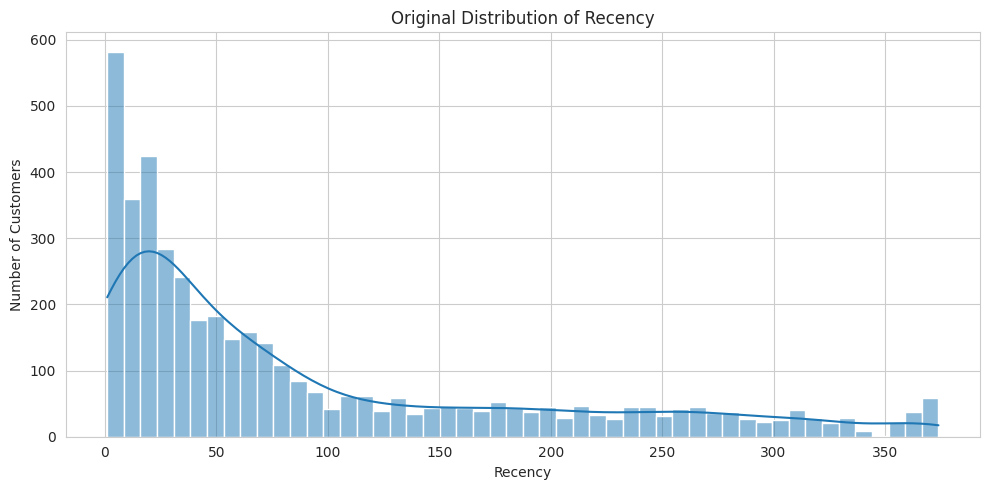

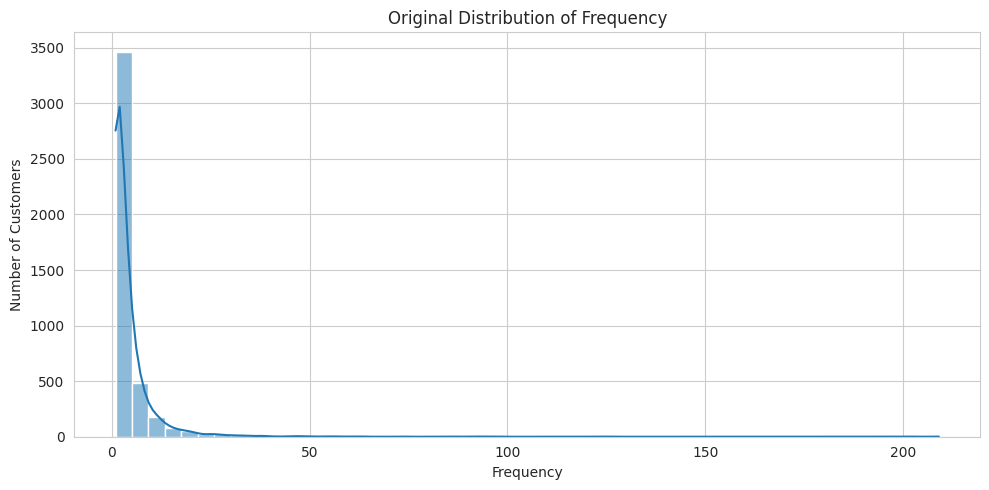

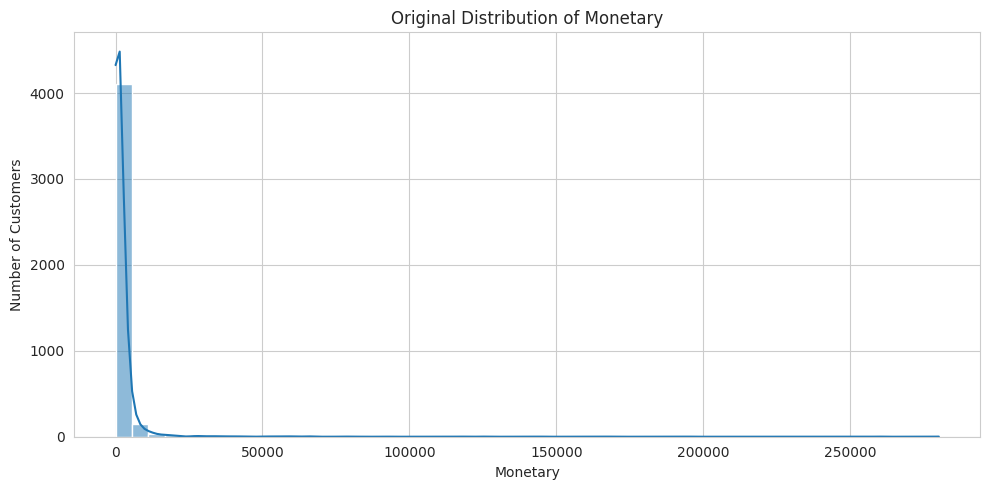

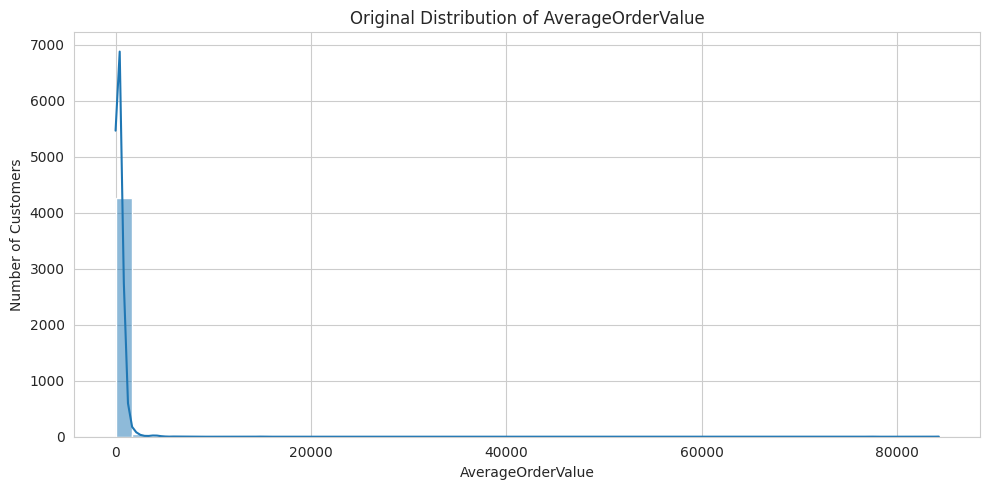

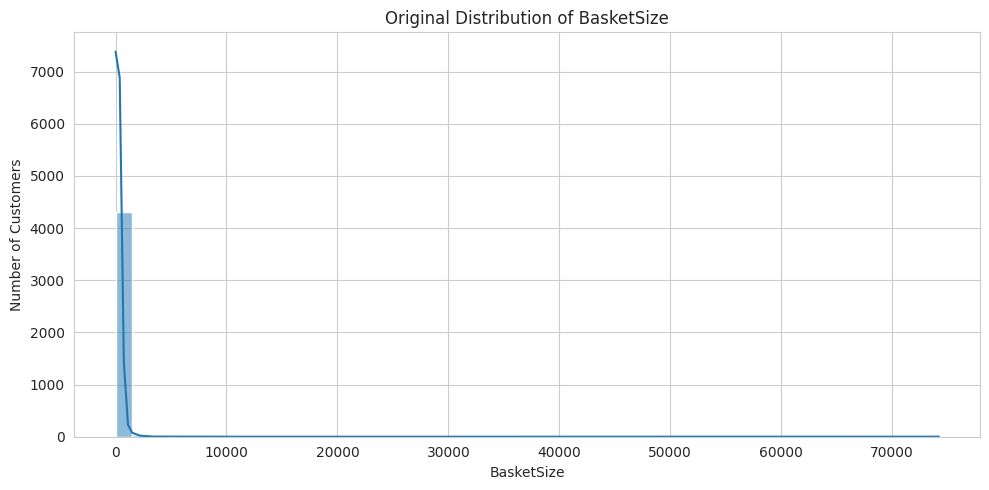

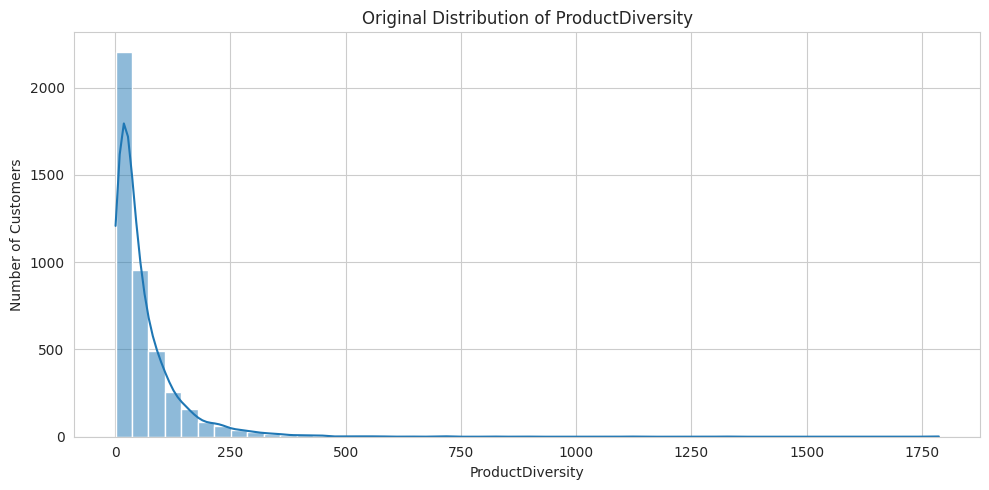

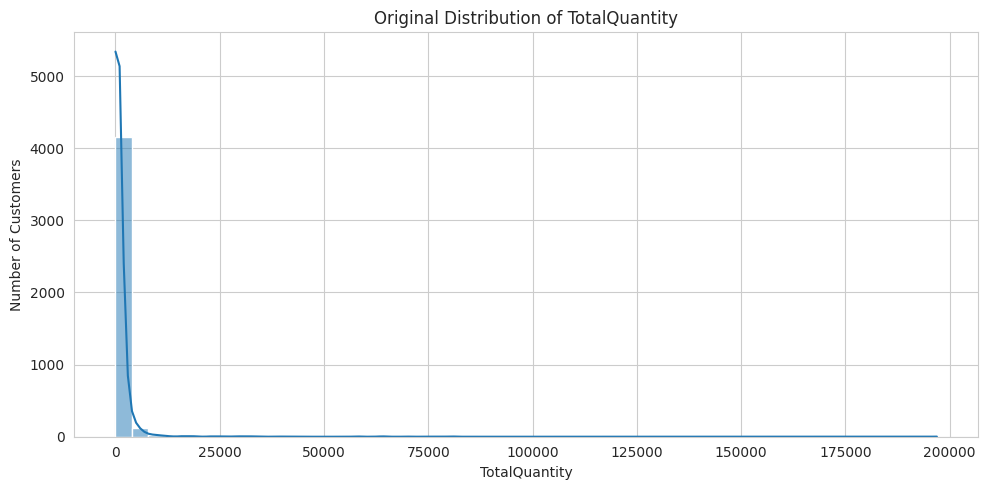

In [44]:
for feature in feature_columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        customer_features[feature],
        bins=50,
        kde=True
    )

    plt.title(
        f"Original Distribution of {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Customers")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            figures_dir,
            f"original_distribution_{feature}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


###  10: Plot boxplots before transformation


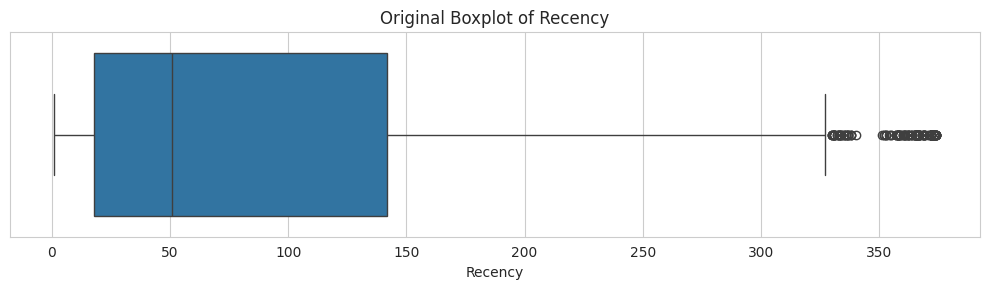

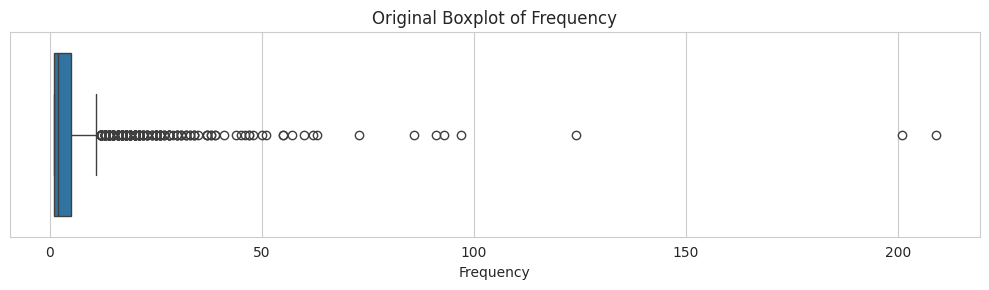

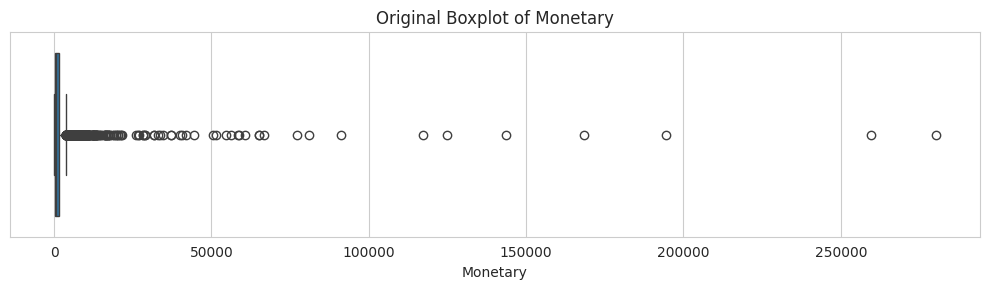

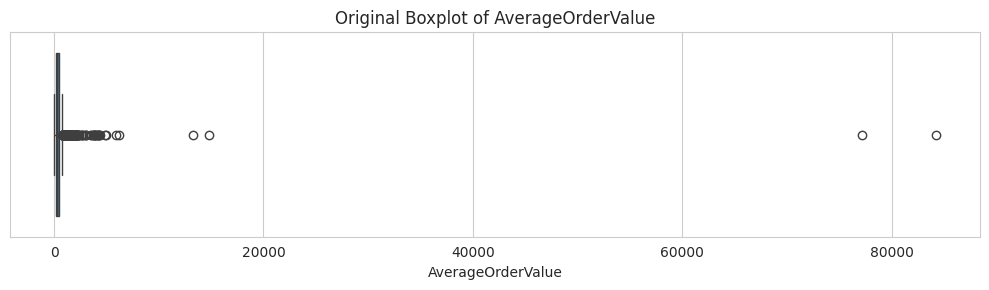

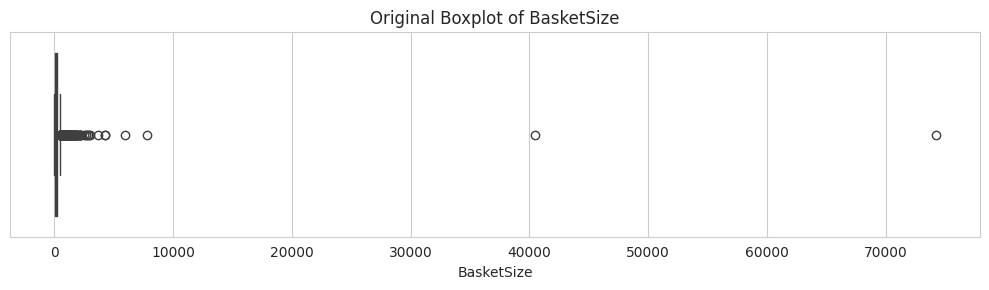

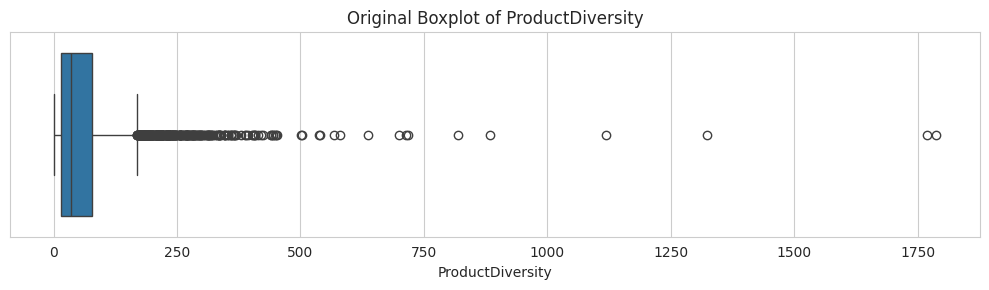

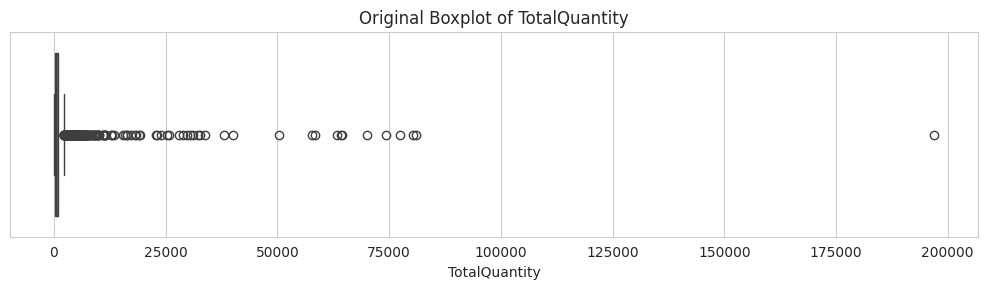

In [45]:
for feature in feature_columns:

    plt.figure(figsize=(10, 3))

    sns.boxplot(
        x=customer_features[feature]
    )

    plt.title(
        f"Original Boxplot of {feature}"
    )

    plt.xlabel(feature)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            figures_dir,
            f"original_boxplot_{feature}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


###  11: Measure skewness and kurtosis


In [46]:
distribution_report_before = pd.DataFrame({
    "Feature": feature_columns,

    "Skewness Before": [
        customer_features[feature].skew()
        for feature in feature_columns
    ],

    "Kurtosis Before": [
        customer_features[feature].kurtosis()
        for feature in feature_columns
    ]
})

print("\nSkewness and kurtosis before transformation:")
display(distribution_report_before)

distribution_report_before.to_csv(
    os.path.join(
        tables_dir,
        "distribution_report_before_transformation.csv"
    ),
    index=False
)



Skewness and kurtosis before transformation:


,Feature,Skewness Before,Kurtosis Before
0,Recency,1.2460,0.4306
1,Frequency,12.0670,249.0581
2,Monetary,19.3394,478.6843
3,AverageOrderValue,41.6924,"1,862.5712"
4,BasketSize,48.0082,"2,527.8996"
5,ProductDiversity,6.9194,99.7536
6,TotalQuantity,20.3840,609.9895


###  12: Analyse possible outliers using the IQR rule


In [47]:
outlier_results = []

for feature in feature_columns:

    q1 = customer_features[feature].quantile(0.25)

    q3 = customer_features[feature].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)

    upper_bound = q3 + (1.5 * iqr)

    outlier_mask = (
        (customer_features[feature] < lower_bound)
        |
        (customer_features[feature] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    outlier_percentage = (
        outlier_count
        / len(customer_features)
        * 100
    )

    outlier_results.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": outlier_percentage
    })

outlier_report = pd.DataFrame(
    outlier_results
).round(4)

print("\nIQR outlier analysis:")
display(outlier_report)

outlier_report.to_csv(
    os.path.join(
        tables_dir,
        "iqr_outlier_analysis.csv"
    ),
    index=False
)

print(
    "\nOutliers are retained because they may represent "
    "genuine high-value or high-volume customers."
)



IQR outlier analysis:


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,Recency,18.0000,142.0000,124.0000,-168.0000,328.0000,155,3.5731
1,Frequency,1.0000,5.0000,4.0000,-5.0000,11.0000,285,6.5698
2,Monetary,306.4825,"1,660.5975","1,354.1150","-1,724.6900","3,691.7700",425,9.7971
3,AverageOrderValue,177.8625,428.2800,250.4175,-197.7638,803.9062,291,6.7082
4,BasketSize,92.0000,270.0000,178.0000,-175.0000,537.0000,264,6.0858
5,ProductDiversity,16.0000,77.0000,61.0000,-75.5000,168.5000,309,7.1231
6,TotalQuantity,159.0000,989.7500,830.7500,"-1,087.1250","2,235.8750",401,9.2439



Outliers are retained because they may represent genuine high-value or high-volume customers.


###  13: Check raw feature variance


In [48]:
raw_variance_report = pd.DataFrame({
    "Feature": feature_columns,

    "Variance": [
        customer_features[feature].var()
        for feature in feature_columns
    ],

    "Unique Values": [
        customer_features[feature].nunique()
        for feature in feature_columns
    ],

    "Constant Feature": [
        customer_features[feature].nunique() <= 1
        for feature in feature_columns
    ]
})

print("\nRaw feature variance report:")
display(raw_variance_report)

raw_variance_report.to_csv(
    os.path.join(
        tables_dir,
        "raw_feature_variance_report.csv"
    ),
    index=False
)

constant_features = raw_variance_report.loc[
    raw_variance_report["Constant Feature"],
    "Feature"
].tolist()

if constant_features:

    raise ValueError(
        f"Constant features detected: {constant_features}"
    )



Raw feature variance report:


,Feature,Variance,Unique Values,Constant Feature
0,Recency,"10,002.8339",349,False
1,Frequency,59.2592,59,False
2,Monetary,"80,734,362.1066",4246,False
3,AverageOrderValue,"3,227,453.0043",4147,False
4,BasketSize,"1,723,363.3184",2129,False
5,ProductDiversity,"7,287.4850",338,False
6,TotalQuantity,"25,438,099.2169",1749,False


###  14: Calculate the raw correlation matrix



Raw feature correlation matrix:


,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
Recency,1.0000,-0.2606,-0.1218,-0.0001,0.0074,-0.3007,-0.1234
Frequency,-0.2606,1.0000,0.5528,0.0191,0.0108,0.6922,0.5572
Monetary,-0.1218,0.5528,1.0000,0.3937,0.3105,0.3858,0.9229
AverageOrderValue,-0.0001,0.0191,0.3937,1.0000,0.9309,0.0360,0.4066
BasketSize,0.0074,0.0108,0.3105,0.9309,1.0000,0.0248,0.3841
ProductDiversity,-0.3007,0.6922,0.3858,0.0360,0.0248,1.0000,0.4088
TotalQuantity,-0.1234,0.5572,0.9229,0.4066,0.3841,0.4088,1.0000


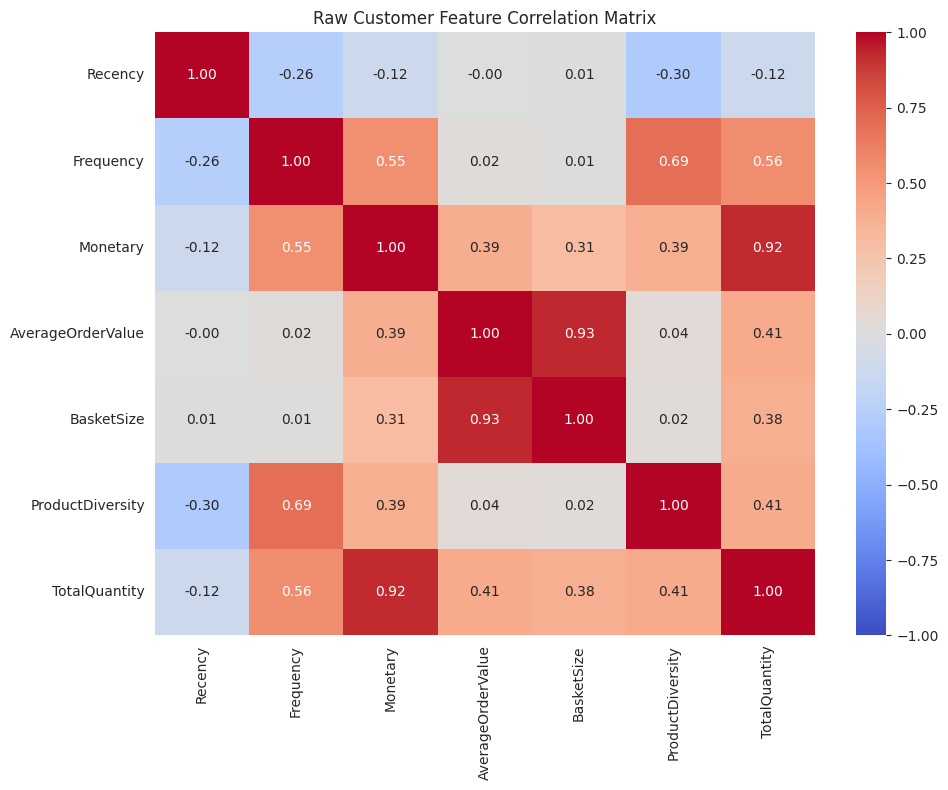

In [49]:
raw_correlation_matrix = (
    customer_features[feature_columns]
    .corr(method="pearson")
)

print("\nRaw feature correlation matrix:")
display(raw_correlation_matrix)

raw_correlation_matrix.to_csv(
    os.path.join(
        tables_dir,
        "raw_feature_correlation_matrix.csv"
    )
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    raw_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title(
    "Raw Customer Feature Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_dir,
        "raw_feature_correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  15: Report highly correlated feature pairs


In [50]:
correlation_threshold = 0.90

high_correlation_pairs = []

for first_index in range(
    len(feature_columns)
):

    for second_index in range(
        first_index + 1,
        len(feature_columns)
    ):

        first_feature = feature_columns[
            first_index
        ]

        second_feature = feature_columns[
            second_index
        ]

        correlation_value = (
            raw_correlation_matrix.loc[
                first_feature,
                second_feature
            ]
        )

        if abs(correlation_value) >= correlation_threshold:

            high_correlation_pairs.append({
                "Feature 1": first_feature,
                "Feature 2": second_feature,
                "Correlation": correlation_value,
                "Absolute Correlation":
                    abs(correlation_value)
            })

high_correlation_report = pd.DataFrame(
    high_correlation_pairs
)

if high_correlation_report.empty:

    high_correlation_report = pd.DataFrame({
        "Feature 1": [],
        "Feature 2": [],
        "Correlation": [],
        "Absolute Correlation": []
    })

print(
    f"\nFeature pairs with absolute correlation "
    f">= {correlation_threshold}:"
)

display(high_correlation_report)

high_correlation_report.to_csv(
    os.path.join(
        tables_dir,
        "high_correlation_feature_pairs.csv"
    ),
    index=False
)



Feature pairs with absolute correlation >= 0.9:


,Feature 1,Feature 2,Correlation,Absolute Correlation
0,Monetary,TotalQuantity,0.9229,0.9229
1,AverageOrderValue,BasketSize,0.9309,0.9309


## Phase 3: Transform the skewed variables


###  16: Choose features for log transformation


In [51]:
log_features = [
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

non_log_features = [
    "Recency"
]

print("\nFeatures selected for log1p transformation:")
print(log_features)

print("\nFeatures not log transformed:")
print(non_log_features)



Features selected for log1p transformation:
['Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']

Features not log transformed:
['Recency']


###  17: Apply the log1p transformation


In [52]:
log_transformed_features = customer_features.copy()

for feature in log_features:

    log_transformed_features[feature] = np.log1p(
        log_transformed_features[feature]
    )

print("\nLog transformation completed.")

display(
    log_transformed_features.head()
)



Log transformation completed.


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,12346,326,0.6931,11.2540,11.2540,11.2147,0.6931,11.2147
1,12347,2,2.0794,8.3689,6.4244,5.8640,4.6444,7.8075
2,12348,75,1.6094,7.4946,6.1099,6.3737,3.1355,7.7588
3,12349,19,0.6931,7.4722,7.4722,6.4489,4.3041,6.4489
4,12350,310,0.6931,5.8153,5.8153,5.2883,2.8904,5.2883


###  18: Validate the transformed values


In [53]:
log_validation_report = pd.DataFrame({
    "Feature": feature_columns,

    "Missing Values": [
        log_transformed_features[feature]
        .isnull()
        .sum()
        for feature in feature_columns
    ],

    "Infinite Values": [
        np.isinf(
            log_transformed_features[feature]
        ).sum()
        for feature in feature_columns
    ],

    "Minimum": [
        log_transformed_features[feature].min()
        for feature in feature_columns
    ],

    "Maximum": [
        log_transformed_features[feature].max()
        for feature in feature_columns
    ]
})

print("\nLog transformation validation:")
display(log_validation_report)

log_validation_report.to_csv(
    os.path.join(
        tables_dir,
        "log_transformation_validation.csv"
    ),
    index=False
)

if not np.isfinite(
    log_transformed_features[feature_columns]
    .to_numpy()
).all():

    raise ValueError(
        "Invalid values detected after log transformation."
    )



Log transformation validation:


,Feature,Missing Values,Infinite Values,Minimum,Maximum
0,Recency,0,0,1.0000,374.0000
1,Frequency,0,0,0.6931,5.3471
2,Monetary,0,0,1.5581,12.5433
3,AverageOrderValue,0,0,1.4929,11.3414
4,BasketSize,0,0,0.6931,11.2147
5,ProductDiversity,0,0,0.6931,7.4889
6,TotalQuantity,0,0,0.6931,12.1905


###  19: Compare distributions before and after transformation


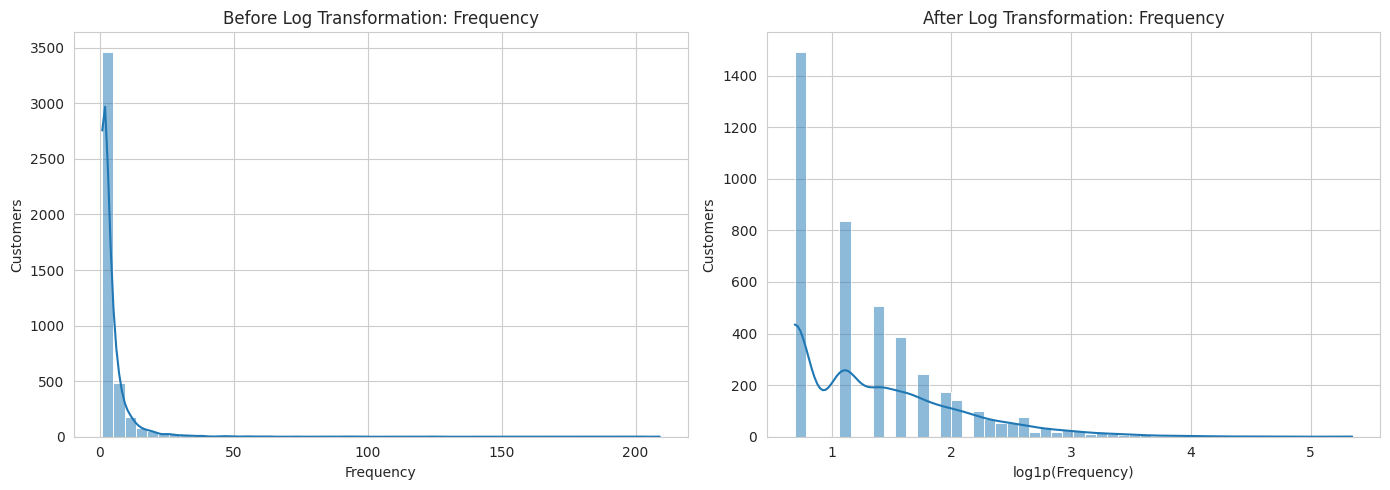

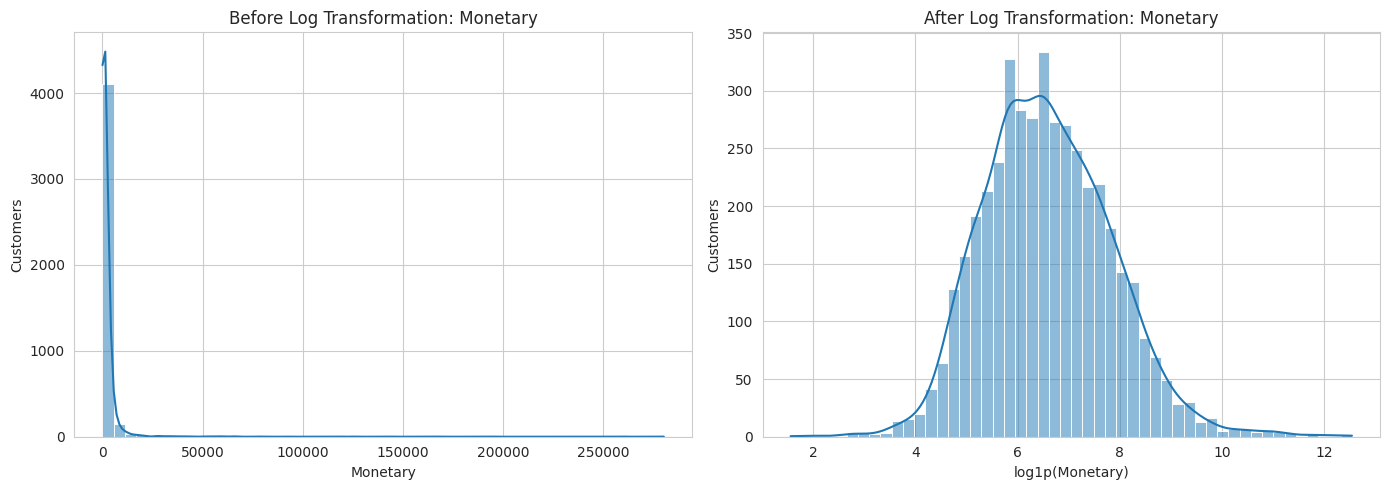

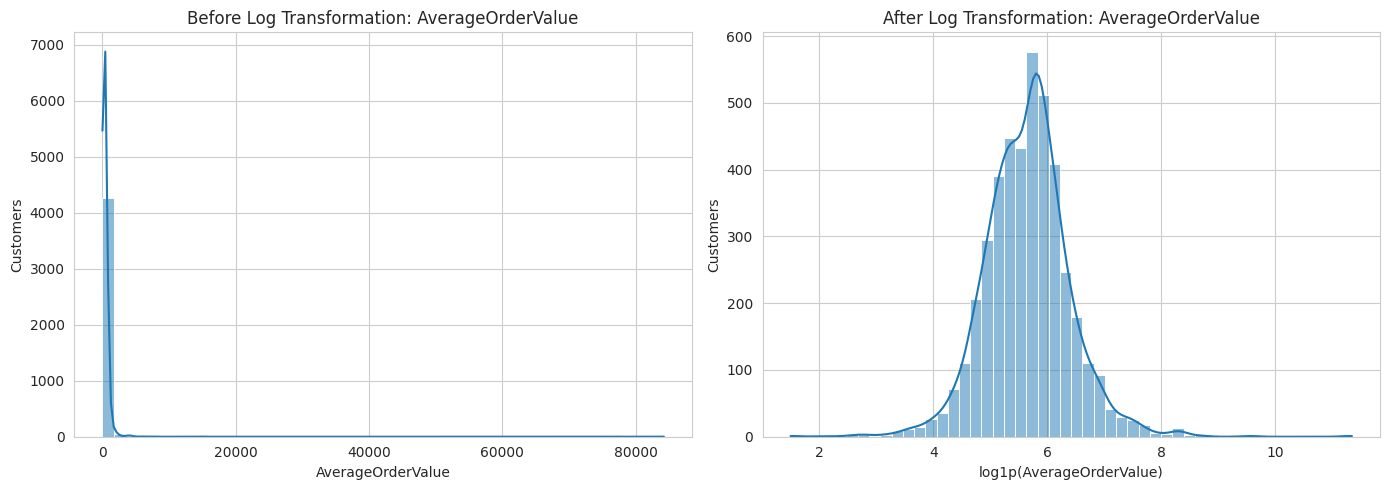

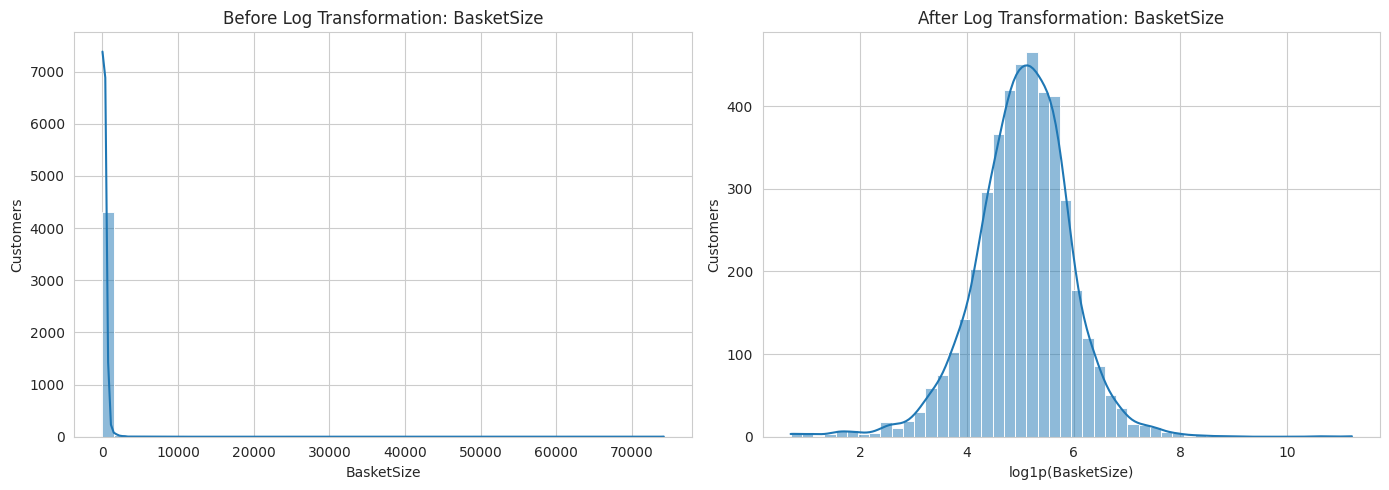

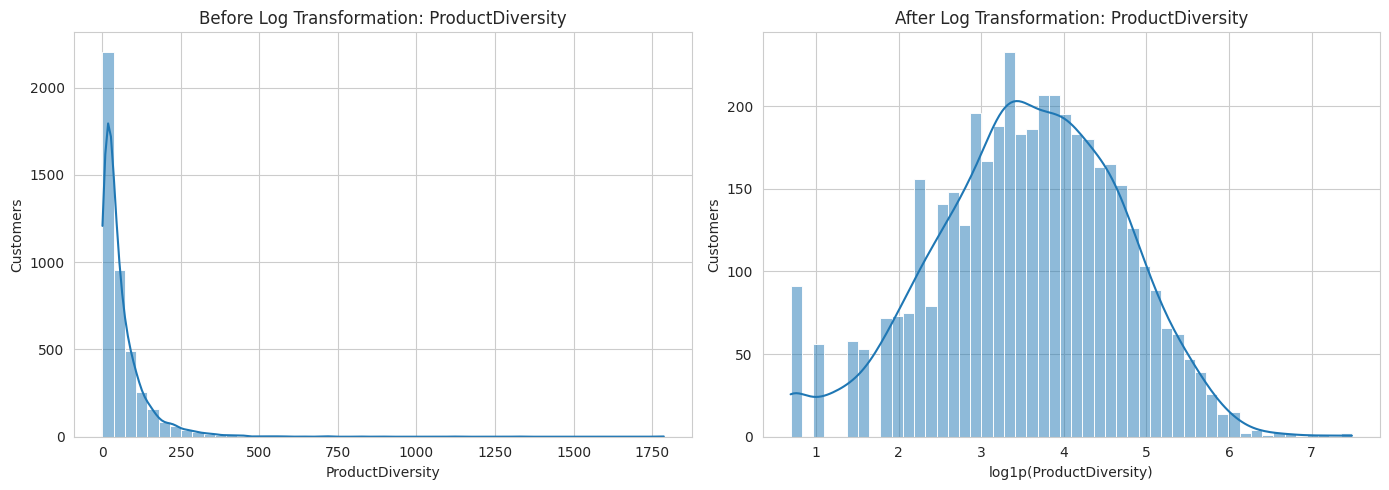

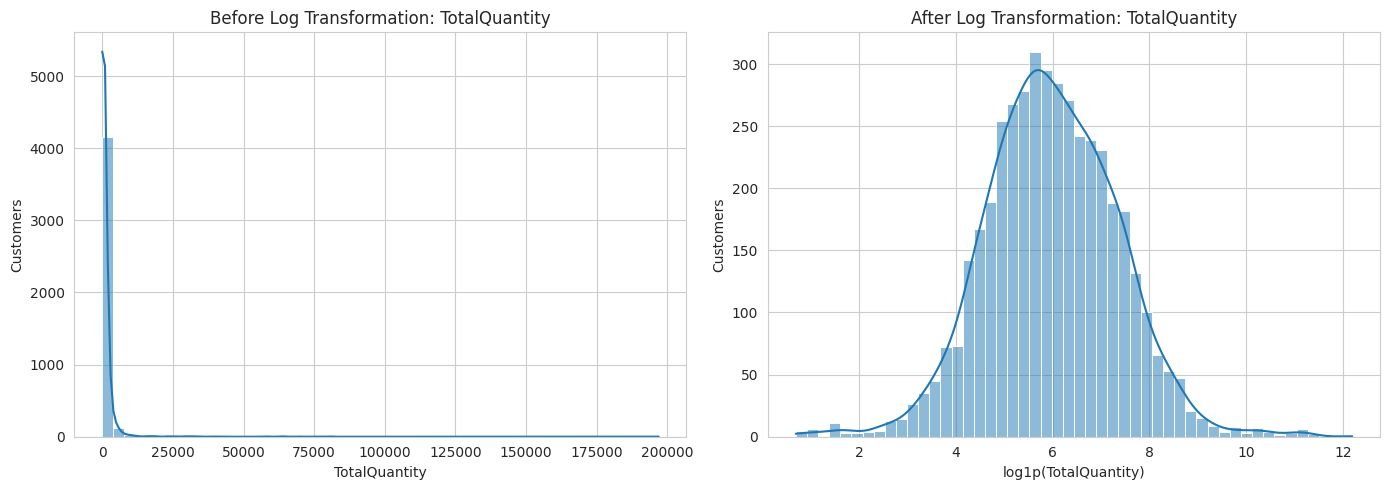

In [54]:
for feature in log_features:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    sns.histplot(
        customer_features[feature],
        bins=50,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(
        f"Before Log Transformation: {feature}"
    )

    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Customers")

    sns.histplot(
        log_transformed_features[feature],
        bins=50,
        kde=True,
        ax=axes[1]
    )

    axes[1].set_title(
        f"After Log Transformation: {feature}"
    )

    axes[1].set_xlabel(
        f"log1p({feature})"
    )

    axes[1].set_ylabel("Customers")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            figures_dir,
            f"before_after_log_{feature}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


###  20: Compare skewness and kurtosis after transformation


In [55]:
distribution_report_after = pd.DataFrame({
    "Feature": feature_columns,

    "Skewness After": [
        log_transformed_features[feature].skew()
        for feature in feature_columns
    ],

    "Kurtosis After": [
        log_transformed_features[feature].kurtosis()
        for feature in feature_columns
    ]
})

distribution_comparison = (
    distribution_report_before
    .merge(
        distribution_report_after,
        on="Feature",
        how="inner"
    )
)

distribution_comparison[
    "Absolute Skewness Reduction"
] = (
    distribution_comparison[
        "Skewness Before"
    ].abs()
    -
    distribution_comparison[
        "Skewness After"
    ].abs()
)

distribution_comparison = (
    distribution_comparison.round(4)
)

print("\nDistribution comparison:")
display(distribution_comparison)

distribution_comparison.to_csv(
    os.path.join(
        tables_dir,
        "distribution_before_after_comparison.csv"
    ),
    index=False
)



Distribution comparison:


,Feature,Skewness Before,Kurtosis Before,Skewness After,Kurtosis After,Absolute Skewness Reduction
0,Recency,1.2460,0.4306,1.2460,0.4306,0.0000
1,Frequency,12.0670,249.0581,1.2087,1.6837,10.8584
2,Monetary,19.3394,478.6843,0.3966,0.7191,18.9428
3,AverageOrderValue,41.6924,"1,862.5712",0.2431,3.3271,41.4494
4,BasketSize,48.0082,"2,527.8996",-0.3561,2.7900,47.6522
5,ProductDiversity,6.9194,99.7536,-0.2433,-0.1110,6.6762
6,TotalQuantity,20.3840,609.9895,0.0446,0.8643,20.3394


###  21: Save the log-transformed dataset


In [56]:
log_transformed_features.to_csv(
    os.path.join(
        data_dir,
        "customer_features_log_transformed.csv"
    ),
    index=False
)


## Phase 4: Check multicollinearity and scale the features


###  22: Check multicollinearity using VIF


In [57]:
vif_input = (
    log_transformed_features[feature_columns]
    .astype(float)
    .copy()
)

vif_report = pd.DataFrame({
    "Feature": feature_columns,

    "VIF": [
        variance_inflation_factor(
            vif_input.values,
            feature_index
        )
        for feature_index in range(
            vif_input.shape[1]
        )
    ]
})

vif_report["Interpretation"] = pd.cut(
    vif_report["VIF"],
    bins=[
        -np.inf,
        5,
        10,
        np.inf
    ],
    labels=[
        "Low or acceptable",
        "Moderate",
        "High"
    ]
)

print("\nVariance Inflation Factor report:")
display(vif_report)

vif_report.to_csv(
    os.path.join(
        tables_dir,
        "vif_multicollinearity_report.csv"
    ),
    index=False
)



Variance Inflation Factor report:


,Feature,VIF,Interpretation
0,Recency,2.6138,Low or acceptable
1,Frequency,213.8938,High
2,Monetary,"1,168,752.2124",High
3,AverageOrderValue,"848,381.0607",High
4,BasketSize,"684,395.4653",High
5,ProductDiversity,22.7273,High
6,TotalQuantity,"973,802.6756",High


###  23: Apply RobustScaler


In [58]:
scaler = RobustScaler()

processed_features = (
    log_transformed_features.copy()
)

processed_features[
    feature_columns
] = scaler.fit_transform(
    log_transformed_features[
        feature_columns
    ]
)

print("\nRobust scaling completed.")

display(processed_features.head())



Robust scaling completed.


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,12346,2.2177,-0.3691,2.8139,6.3667,5.7289,-1.8972,2.8943
1,12347,-0.3952,0.8928,1.1038,0.8503,0.7260,0.6963,1.0256
2,12348,0.1935,0.4650,0.5856,0.4911,1.2025,-0.2941,0.9989
3,12349,-0.2581,-0.3691,0.5723,2.0472,1.2728,0.4730,0.2805
4,12350,2.0887,-0.3691,-0.4098,0.1546,0.1876,-0.4550,-0.3561


###  24: Save the fitted scaler


In [59]:
joblib.dump(
    scaler,
    os.path.join(
        models_dir,
        "fitted_robust_scaler.joblib"
    )
)

scaler_parameters = pd.DataFrame({
    "Feature": feature_columns,
    "Center_Median": scaler.center_,
    "Scale_IQR": scaler.scale_
})

print("\nRobustScaler parameters:")
display(scaler_parameters)

scaler_parameters.to_csv(
    os.path.join(
        tables_dir,
        "robust_scaler_parameters.csv"
    ),
    index=False
)



RobustScaler parameters:


,Feature,Center_Median,Scale_IQR
0,Recency,51.0000,124.0000
1,Frequency,1.0986,1.0986
2,Monetary,6.5066,1.6871
3,AverageOrderValue,5.6800,0.8755
4,BasketSize,5.0876,1.0695
5,ProductDiversity,3.5835,1.5235
6,TotalQuantity,5.9375,1.8233


###  25: Verify the scaled values


In [60]:
scaled_feature_report = pd.DataFrame({
    "Feature": feature_columns,

    "Mean": [
        processed_features[feature].mean()
        for feature in feature_columns
    ],

    "Median": [
        processed_features[feature].median()
        for feature in feature_columns
    ],

    "Standard Deviation": [
        processed_features[feature].std()
        for feature in feature_columns
    ],

    "Q1": [
        processed_features[feature].quantile(0.25)
        for feature in feature_columns
    ],

    "Q3": [
        processed_features[feature].quantile(0.75)
        for feature in feature_columns
    ],

    "IQR": [
        (
            processed_features[feature].quantile(0.75)
            -
            processed_features[feature].quantile(0.25)
        )
        for feature in feature_columns
    ],

    "Minimum": [
        processed_features[feature].min()
        for feature in feature_columns
    ],

    "Maximum": [
        processed_features[feature].max()
        for feature in feature_columns
    ]
}).round(4)

print("\nScaled feature verification report:")
display(scaled_feature_report)

scaled_feature_report.to_csv(
    os.path.join(
        tables_dir,
        "scaled_feature_verification_report.csv"
    ),
    index=False
)



Scaled feature verification report:


,Feature,Mean,Median,Standard Deviation,Q1,Q3,IQR,Minimum,Maximum
0,Recency,0.3350,0.0000,0.8066,-0.2661,0.7339,1.0000,-0.4032,2.6048
1,Frequency,0.2248,0.0000,0.6218,-0.3691,0.6309,1.0000,-0.3691,3.8671
2,Monetary,0.0486,-0.0000,0.7459,-0.4613,0.5387,1.0000,-2.9331,3.5781
3,AverageOrderValue,-0.0388,0.0000,0.8516,-0.5635,0.4365,1.0000,-4.7825,6.4666
4,BasketSize,-0.0439,0.0000,0.8450,-0.5189,0.4811,1.0000,-4.1088,5.7289
5,ProductDiversity,-0.0210,0.0000,0.7427,-0.4925,0.5075,1.0000,-1.8972,2.5634
6,TotalQuantity,0.0239,0.0000,0.7517,-0.4730,0.5270,1.0000,-2.8763,3.4295


###  26: Plot the scaled feature distributions


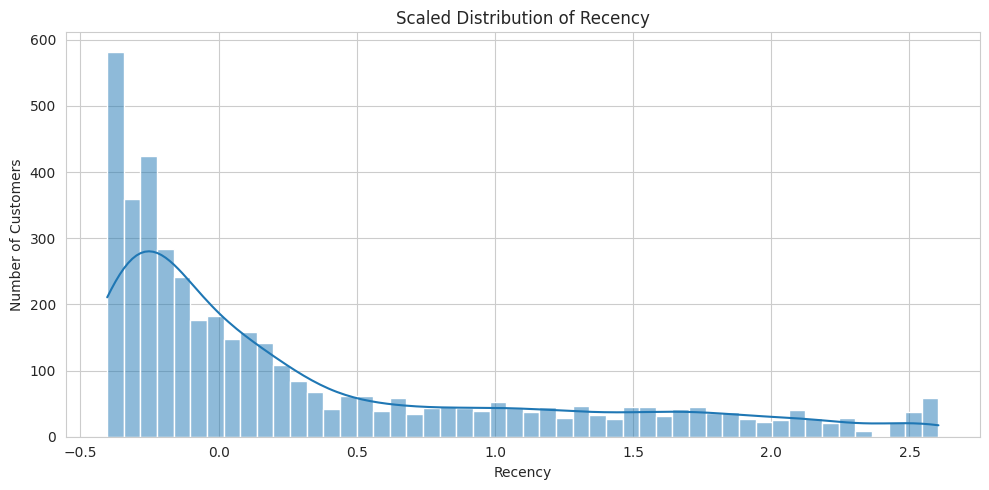

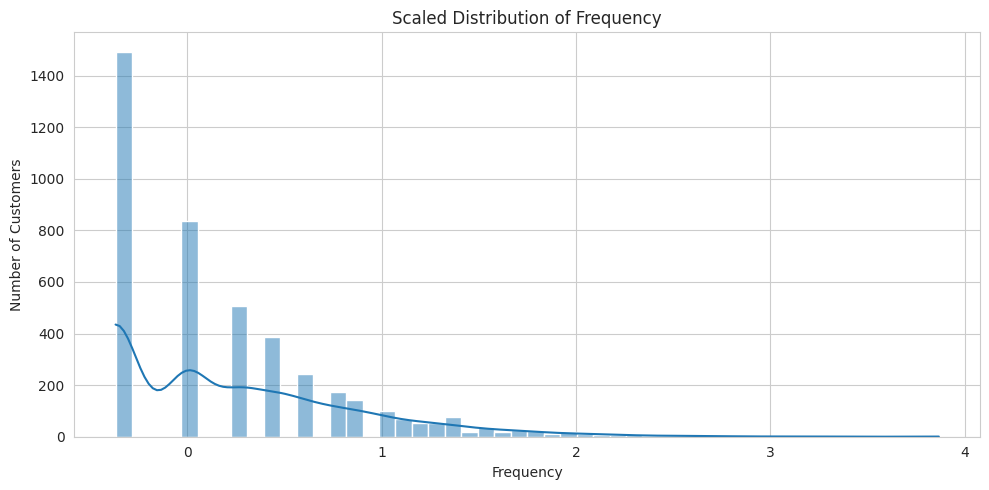

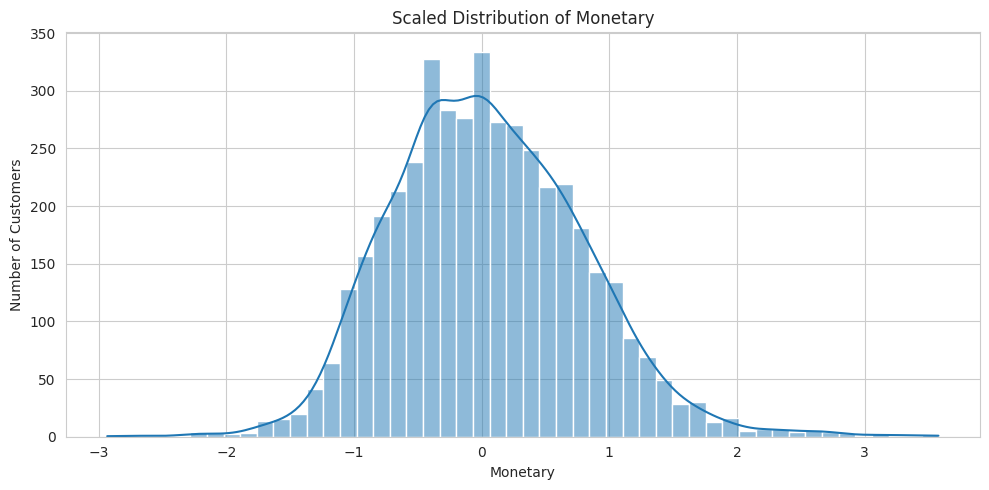

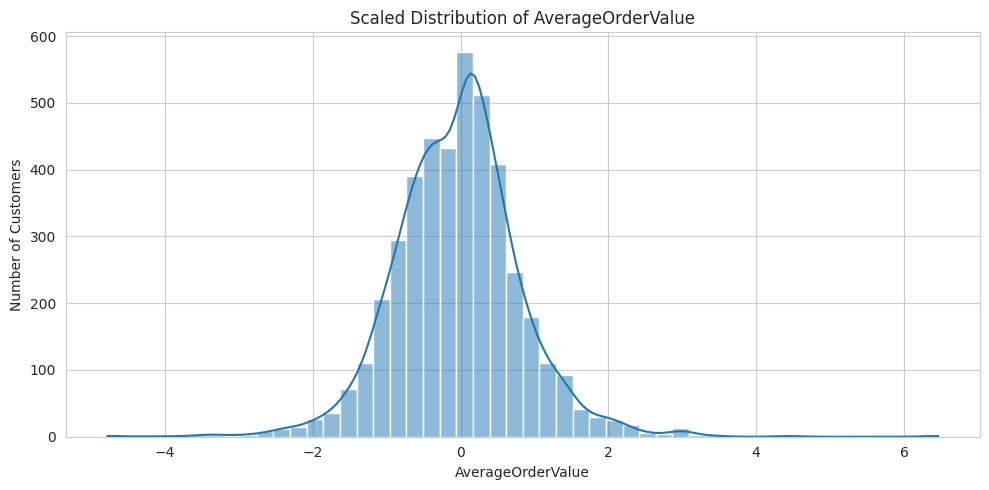

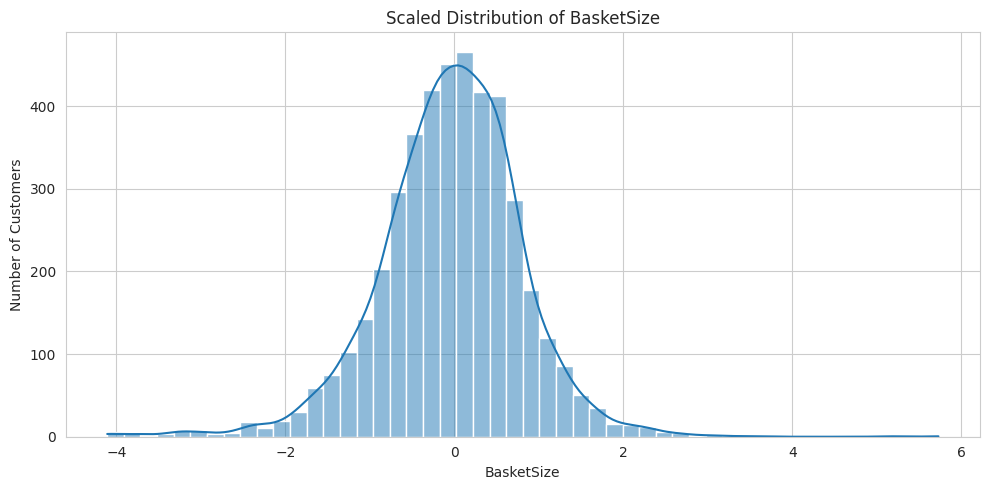

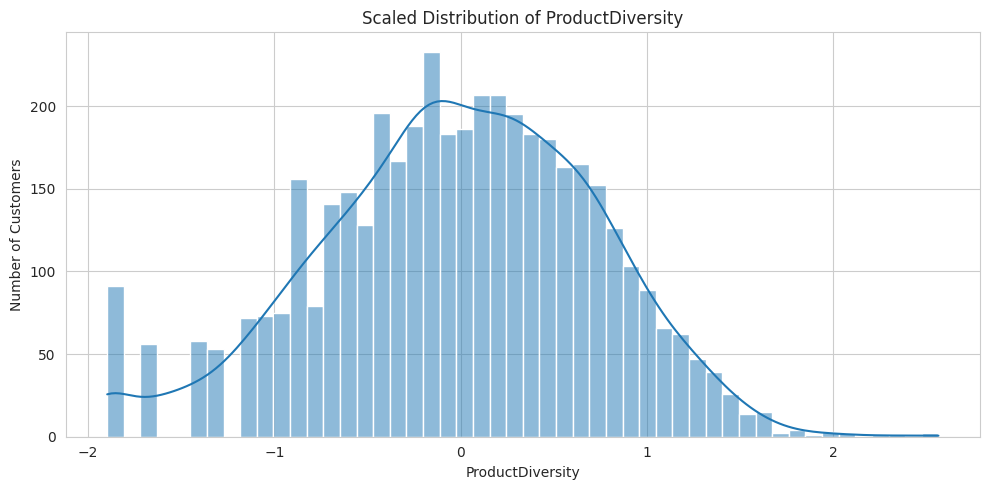

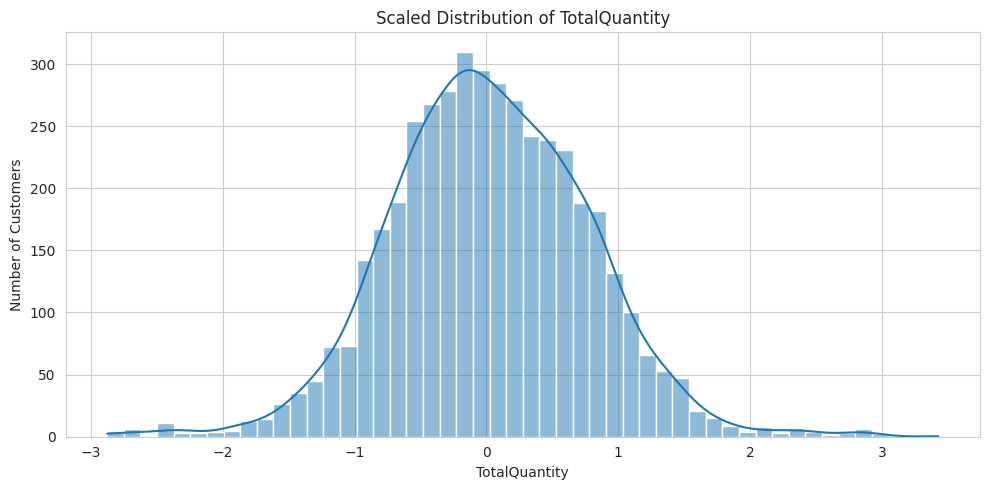

In [61]:
for feature in feature_columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        processed_features[feature],
        bins=50,
        kde=True
    )

    plt.title(
        f"Scaled Distribution of {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Customers")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            figures_dir,
            f"scaled_distribution_{feature}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


###  27: Recheck correlation after scaling



Scaled feature correlation matrix:


,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
Recency,1.0000,-0.4728,-0.4342,-0.1386,-0.1968,-0.4184,-0.4527
Frequency,-0.4728,1.0000,0.8081,0.1643,0.1527,0.6227,0.7525
Monetary,-0.4342,0.8081,1.0000,0.7089,0.5902,0.6924,0.9217
AverageOrderValue,-0.1386,0.1643,0.7089,1.0000,0.8104,0.4030,0.6422
BasketSize,-0.1968,0.1527,0.5902,0.8104,1.0000,0.4323,0.7621
ProductDiversity,-0.4184,0.6227,0.6924,0.4030,0.4323,1.0000,0.7017
TotalQuantity,-0.4527,0.7525,0.9217,0.6422,0.7621,0.7017,1.0000


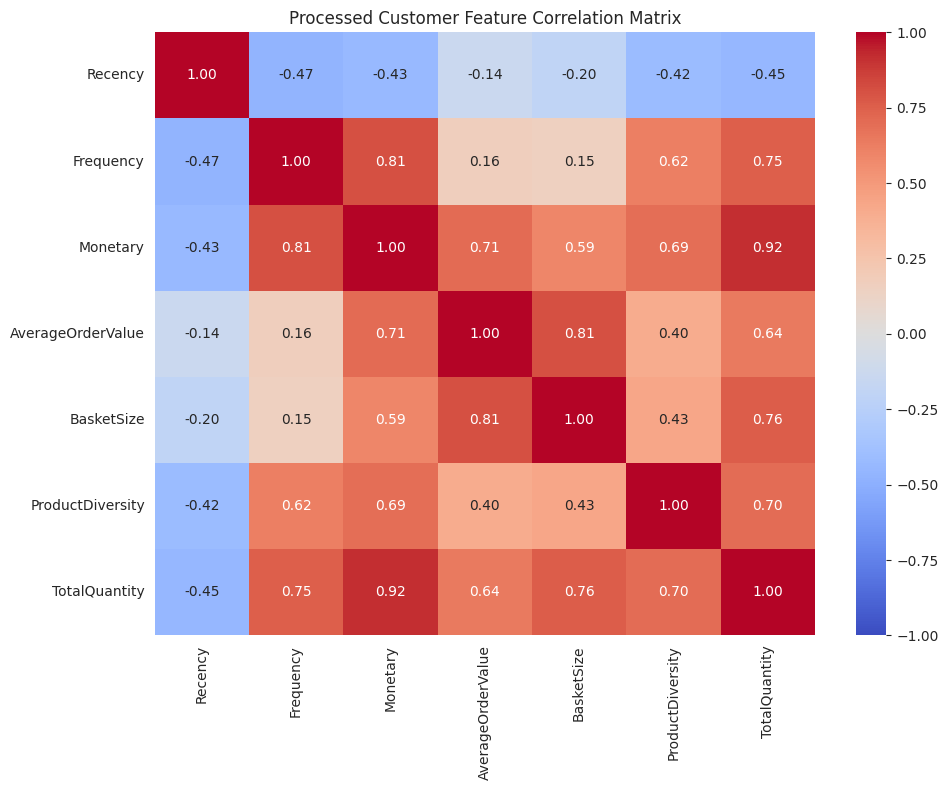

In [62]:
scaled_correlation_matrix = (
    processed_features[feature_columns]
    .corr(method="pearson")
)

print("\nScaled feature correlation matrix:")
display(scaled_correlation_matrix)

scaled_correlation_matrix.to_csv(
    os.path.join(
        tables_dir,
        "scaled_feature_correlation_matrix.csv"
    )
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    scaled_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title(
    "Processed Customer Feature Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_dir,
        "processed_feature_correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  28: Check for near-zero variance


In [63]:
processed_variance_report = pd.DataFrame({
    "Feature": feature_columns,

    "Variance": [
        processed_features[feature].var()
        for feature in feature_columns
    ],

    "Unique Values": [
        processed_features[feature].nunique()
        for feature in feature_columns
    ]
})

processed_variance_report[
    "Near Zero Variance"
] = (
    processed_variance_report[
        "Variance"
    ] < 0.01
)

print("\nProcessed feature variance report:")
display(processed_variance_report)

processed_variance_report.to_csv(
    os.path.join(
        tables_dir,
        "processed_feature_variance_report.csv"
    ),
    index=False
)



Processed feature variance report:


,Feature,Variance,Unique Values,Near Zero Variance
0,Recency,0.6505,349,False
1,Frequency,0.3866,59,False
2,Monetary,0.5564,4240,False
3,AverageOrderValue,0.7252,4147,False
4,BasketSize,0.7140,2129,False
5,ProductDiversity,0.5517,338,False
6,TotalQuantity,0.5651,1749,False


## Phase 5: Exploratory PCA and final validation


###  29: Create a two-dimensional PCA view



PCA explained variance:


,Principal Component,Explained Variance Ratio,Explained Variance Percentage
0,PC1,0.6156,61.5640
1,PC2,0.1980,19.8007


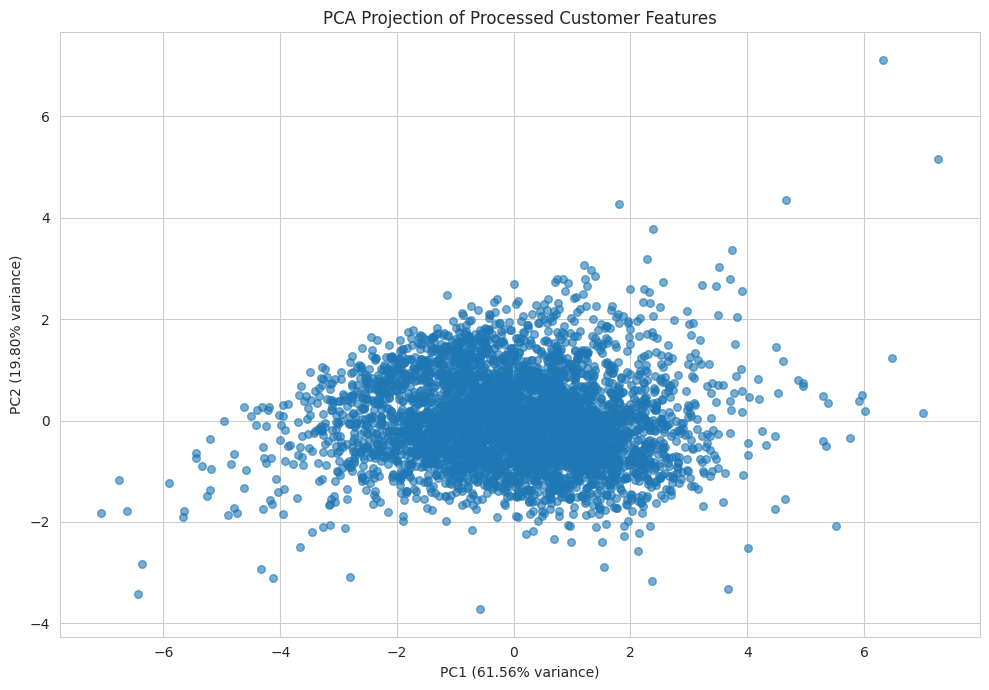

In [64]:
# PCA IS NOT USED AS THE CLUSTERING INPUT

pca = PCA(
    n_components=2,
    random_state=42
)

pca_coordinates = pca.fit_transform(
    processed_features[feature_columns]
)

pca_dataframe = pd.DataFrame({
    "CustomerID":
        processed_features["CustomerID"],

    "PC1":
        pca_coordinates[:, 0],

    "PC2":
        pca_coordinates[:, 1]
})

pca_variance_report = pd.DataFrame({
    "Principal Component": [
        "PC1",
        "PC2"
    ],

    "Explained Variance Ratio":
        pca.explained_variance_ratio_,

    "Explained Variance Percentage":
        pca.explained_variance_ratio_
        * 100
})

print("\nPCA explained variance:")
display(pca_variance_report)

pca_variance_report.to_csv(
    os.path.join(
        tables_dir,
        "pca_explained_variance_report.csv"
    ),
    index=False
)

pca_dataframe.to_csv(
    os.path.join(
        data_dir,
        "customer_features_pca_visualisation.csv"
    ),
    index=False
)

plt.figure(figsize=(10, 7))

plt.scatter(
    pca_dataframe["PC1"],
    pca_dataframe["PC2"],
    alpha=0.60,
    s=30
)

plt.title(
    "PCA Projection of Processed Customer Features"
)

plt.xlabel(
    f"PC1 "
    f"({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 "
    f"({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_dir,
        "pca_projection_before_clustering.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  30: Validate the final processed dataset


In [65]:
expected_column_order = [
    "CustomerID"
] + feature_columns

processed_features = processed_features[
    expected_column_order
].copy()

final_validation_report = pd.DataFrame({
    "Validation Check": [
        "Expected columns present",
        "TransactionCount removed",
        "Missing values",
        "Duplicate Customer IDs",
        "Infinite values",
        "Constant features",
        "Near-zero variance features",
        "Customer count unchanged",
        "Ready for clustering"
    ],

    "Result": [
        list(processed_features.columns)
        == expected_column_order,

        "TransactionCount"
        not in processed_features.columns,

        processed_features
        .isnull()
        .sum()
        .sum(),

        processed_features[
            "CustomerID"
        ]
        .duplicated()
        .sum(),

        np.isinf(
            processed_features[
                feature_columns
            ]
            .to_numpy()
        )
        .sum(),

        len(
            processed_variance_report.loc[
                processed_variance_report[
                    "Unique Values"
                ] <= 1
            ]
        ),

        len(
            processed_variance_report.loc[
                processed_variance_report[
                    "Near Zero Variance"
                ]
            ]
        ),

        len(processed_features)
        == len(customer_features),

        "YES"
    ]
})

print("\nFinal preprocessing validation report:")
display(final_validation_report)

final_validation_report.to_csv(
    os.path.join(
        tables_dir,
        "final_preprocessing_validation_report.csv"
    ),
    index=False
)



Final preprocessing validation report:


,Validation Check,Result
0,Expected columns present,True
1,TransactionCount removed,True
2,Missing values,0
3,Duplicate Customer IDs,0
4,Infinite values,0
5,Constant features,0
6,Near-zero variance features,0
7,Customer count unchanged,True
8,Ready for clustering,YES


###  31: Run final assertion checks


In [66]:
assert list(
    processed_features.columns
) == expected_column_order

assert (
    "TransactionCount"
    not in processed_features.columns
)

assert (
    processed_features
    .isnull()
    .sum()
    .sum()
    == 0
)

assert (
    processed_features[
        "CustomerID"
    ]
    .duplicated()
    .sum()
    == 0
)

assert np.isfinite(
    processed_features[
        feature_columns
    ]
    .to_numpy()
).all()

assert (
    len(processed_features)
    == len(customer_features)
)

print(
    "\nAll final preprocessing validation checks passed."
)



All final preprocessing validation checks passed.


###  32: Export the processed clustering dataset


In [67]:
processed_output_path = os.path.join(
    data_dir,
    "customer_features_processed.csv"
)

processed_features.to_csv(
    processed_output_path,
    index=False
)

print("\nFinal processed dataset saved successfully.")

print("\nOutput path:")
print(processed_output_path)

print("\nFinal processed dataset shape:")
print(processed_features.shape)

print("\nFinal processed columns:")
print(processed_features.columns.tolist())

display(processed_features.head())



Final processed dataset saved successfully.

Output path:
Advanced_Preprocessing_Results/Data/customer_features_processed.csv

Final processed dataset shape:
(4338, 8)

Final processed columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,12346,2.2177,-0.3691,2.8139,6.3667,5.7289,-1.8972,2.8943
1,12347,-0.3952,0.8928,1.1038,0.8503,0.7260,0.6963,1.0256
2,12348,0.1935,0.4650,0.5856,0.4911,1.2025,-0.2941,0.9989
3,12349,-0.2581,-0.3691,0.5723,2.0472,1.2728,0.4730,0.2805
4,12350,2.0887,-0.3691,-0.4098,0.1546,0.1876,-0.4550,-0.3561


###  33: Create a preprocessing summary


In [68]:
preprocessing_summary = pd.DataFrame({
    "Stage": [
        "Input Dataset",
        "Remove Unused Features",
        "Raw Validation",
        "Distribution Assessment",
        "Outlier Analysis",
        "Correlation Analysis",
        "Variance Analysis",
        "Log Transformation",
        "VIF Analysis",
        "Robust Scaling",
        "Scaling Verification",
        "PCA Visualisation",
        "Final Validation",
        "Export"
    ],

    "Status": [
        "Completed",
        "Completed",
        "Passed",
        "Completed",
        "Completed - Outliers Retained",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Passed",
        "Completed - Visualisation Only",
        "Passed",
        "Completed"
    ],

    "Details": [
        str(customer_features_original.shape),
        str(unexpected_columns),
        "No missing, duplicate or invalid values",
        "Skewness, kurtosis, histograms and boxplots",
        "IQR method used; genuine customers retained",
        f"Threshold = {correlation_threshold}",
        "Constant and near-zero variance checks",
        str(log_features),
        "Multicollinearity assessed after transformation",
        "All seven clustering features scaled",
        "Median and IQR checked",
        "Two principal components generated",
        "Dataset confirmed ready for clustering",
        processed_output_path
    ]
})

print("\nPreprocessing pipeline summary:")
display(preprocessing_summary)

preprocessing_summary.to_csv(
    os.path.join(
        tables_dir,
        "advanced_preprocessing_summary.csv"
    ),
    index=False
)



Preprocessing pipeline summary:


,Stage,Status,Details
0,Input Dataset,Completed,"(4338, 9)"
1,Remove Unused Features,Completed,['TransactionCount']
2,Raw Validation,Passed,"No missing, duplicate or invalid values"
3,Distribution Assessment,Completed,"Skewness, kurtosis, histograms and boxplots"
4,Outlier Analysis,Completed - Outliers Retained,IQR method used; genuine customers retained
5,Correlation Analysis,Completed,Threshold = 0.9
6,Variance Analysis,Completed,Constant and near-zero variance checks
7,Log Transformation,Completed,"['Frequency', 'Monetary', 'AverageOrderValue',..."
8,VIF Analysis,Completed,Multicollinearity assessed after transformation
9,Robust Scaling,Completed,All seven clustering features scaled


###  34: Display the completion summary


In [69]:

print("ADVANCED PREPROCESSING COMPLETED SUCCESSFULLY")


print("\nFinal clustering features:")

for feature in feature_columns:
    print(f"- {feature}")

print("\nTransactionCount was removed.")

print("\nOutliers were analysed but retained.")

print("\nLog transformation was applied to:")
print(log_features)

print("\nRobust scaling was applied to all clustering features.")

print("\nThe processed dataset is ready for K-Means clustering.")

print("\nMain output file:")
print(processed_output_path)


ADVANCED PREPROCESSING COMPLETED SUCCESSFULLY

Final clustering features:
- Recency
- Frequency
- Monetary
- AverageOrderValue
- BasketSize
- ProductDiversity
- TotalQuantity

TransactionCount was removed.

Outliers were analysed but retained.

Log transformation was applied to:
['Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']

Robust scaling was applied to all clustering features.

The processed dataset is ready for K-Means clustering.

Main output file:
Advanced_Preprocessing_Results/Data/customer_features_processed.csv


# Final Data-Preparation Summary

The complete preparation pipeline is now finished.

**Raw transactions** → cleaned transactions → **4,338 customer records** → seven final clustering features.

The final clustering variables are:

1. Recency
2. Frequency
3. Monetary
4. AverageOrderValue
5. BasketSize
6. ProductDiversity
7. TotalQuantity

`TransactionCount` is retained during exploratory feature engineering but removed before clustering because it overlaps strongly with the Frequency definition used in the final framework.

The primary file for the next notebook is:

`Advanced_Preprocessing_Results/Data/customer_features_processed.csv`

The corresponding original-scale customer feature data remains available at:

`Results/Data/customer_features_ready_for_preprocessing.csv`


## Final Step: Package All Results into One ZIP

This cell packages the complete outputs from data cleaning, feature engineering and advanced preprocessing into one ZIP file for reproducibility and submission.


In [70]:
# PACKAGE ALL RESULTS INTO ONE ZIP

import os
import zipfile

zip_filename = "01_Data_Preparation_and_Feature_Engineering_All_Results.zip"

folders_to_package = [
    "Results",
    "Advanced_Preprocessing_Results"
]

with zipfile.ZipFile(
    zip_filename,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for folder in folders_to_package:

        if not os.path.exists(folder):
            print(f"Warning: {folder} does not exist and was skipped.")
            continue

        for root, directories, files in os.walk(folder):

            for filename in files:
                file_path = os.path.join(root, filename)

                zip_file.write(
                    file_path,
                    arcname=file_path
                )

print("=" * 80)
print("RESULT PACKAGE CREATED SUCCESSFULLY")
print("=" * 80)
print("ZIP file:", zip_filename)
print("Included folders:")
for folder in folders_to_package:
    print("-", folder)

# Download automatically when the notebook is running in Google Colab.
try:
    from google.colab import files
    files.download(zip_filename)
except ImportError:
    print("Not running in Google Colab. The ZIP remains in the current working directory.")



RESULT PACKAGE CREATED SUCCESSFULLY
ZIP file: 01_Data_Preparation_and_Feature_Engineering_All_Results.zip
Included folders:
- Results
- Advanced_Preprocessing_Results


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>